In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines

In [2]:
from alphagenome_pytorch.plotting.splicing import (
    plot_splice_site_dynamics, plot_splice_site_predictions, plot_usage_density,
    SPLICE_CLASS_NAMES,
    BACKGROUND_CLASS,
    CLASS_LABELS,
    CLASS_COLORS,
    TISSUE_COLORS,
    TISSUE_ORDER,
    SPECIES_ORDER,
    SPECIES,
    SPECIES_SCI,
    CHR_SIZES
)

CLASS_LABELS = {
    0: 'Donor+',
    1: 'Donor-',
    2: 'Acceptor+',
    3: 'Acceptor-',
    4: 'Binary'
}

## Load data

In [3]:
# Collect metrics for plotting
metrics_dict = {}

# Load saved predictions 
base_dir = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai"
models = [
    "human", 
    "mouse",
    "human_mouse", 
    "human_mouse_rat", 
    "human_mouse_rat_rabbit", 
    "human_mouse_rabbit_opossum",
    "human_rat_rabbit_opossum",
    "human_mouse_rat_rabbit_opossum"
]
model_names = [
    "132kb_encode_intersect_usage_pc_obs_human",
    "132kb_encode_intersect_usage_pc_obs_mouse",
    "132kb_encode_intersect_usage_pc_obs_human_mouse",
    "132kb_encode_intersect_usage_pc_obs_human_mouse_rat",
    "132kb_encode_intersect_usage_pc_obs_human_mouse_rat_rabbit",
    "132kb_encode_intersect_usage_pc_obs_human_rat_rabbit_opossum",
    "lora_32_human_mouse_rabbit_opossum",
    "lora_32_human_mouse_rat_rabbit_opossum"
]

# Shades of blue for different models
MODEL_COLORS = {
    "human": "#b3cbeb",
    "mouse": "#b3cbeb",
    "human_mouse": "#9ecae1",
    "human_mouse_rat": "#7cb3d1",
    "human_mouse_rat_rabbit": "#4292c6",
    "human_mouse_rabbit_opossum": "#2171b5",
    "human_rat_rabbit_opossum": "#196293",
    "human_mouse_rat_rabbit_opossum": "#05416C"
}

# Mapping model names to short letter codes
MODEL_LETTERS = {
    'human': 'h',
    'mouse': 'm',
    'human_mouse': 'hm',
    'human_mouse_rat': 'hmr',
    'human_mouse_rat_rabbit': 'hmrr',
    'human_mouse_rabbit_opossum': 'hmro',
    'human_rat_rabbit_opossum': 'hrro',
    'human_mouse_rat_rabbit_opossum': 'hmrro',
}

# Shades for different species
SPECIES_COLORS = {
    'human': "#80b1d3",
    'mouse': "#b3de69",
    'rat': "#fdb462",
    'rabbit': "#fb8072",
    'opossum': "#bebada",
    "chicken": "#ffffb3",
    "macaque": "#8dd3c7",
}

# Generate shades from light to dark for each tissue
import matplotlib.colors as mcolors
def make_tissue_shades(base_color, n):
    """From a light tint to the full base color."""
    base = mcolors.to_rgb(base_color)
    return [
        tuple(1 - (1 - c) * (i + 1) / n for c in base)
        for i in range(n)
    ]

n_models = len(models)
TISSUE_MODEL_COLORS = {
    tissue: dict(zip(models, make_tissue_shades(TISSUE_COLORS[tissue], n_models)))
    for tissue in TISSUE_ORDER
}


Load loss data.

In [4]:
loss_dict = {}
for model, model_name in zip(models, model_names):
    log_file = os.path.join(base_dir, model_name, "epoch_log.csv")
    if not os.path.exists(log_file):
        print(f"Log file not found for model {model_name}: {log_file}")
        continue
    df = pd.read_csv(log_file, usecols=['epoch', 'train_loss', 'val_loss'])
    loss_dict[model] = df

# Collect loss data, combine by column names
loss_df = pd.DataFrame()
for model, df in loss_dict.items():
    df = df.copy()
    df['model'] = model
    loss_df = pd.concat([loss_df, df], ignore_index=True)

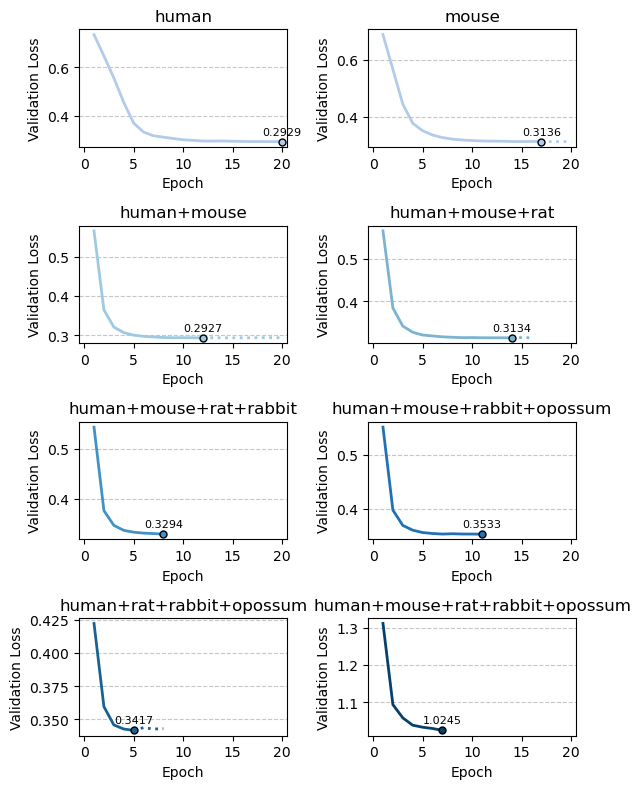

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Only keep models that actually have data
valid_models = [m for m in models if m in loss_dict]
n_models = len(valid_models)

ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2 * nrows), squeeze=False)
axes = axes.flatten()

for ax, model in zip(axes, valid_models):
    df = loss_dict[model]
    color = MODEL_COLORS[model]

    min_epoch_idx = df['val_loss'].idxmin()
    best_epoch = df.loc[min_epoch_idx, 'epoch']

    # Split into solid (up to and including best epoch) and dotted (after) segments
    solid = df[df['epoch'] <= best_epoch]
    dotted = df[df['epoch'] >= best_epoch]  # include best_epoch so lines connect

    ax.plot(solid['epoch'], solid['val_loss'], color=color, linewidth=2,
            linestyle='-', zorder=3, label=model)
    if len(dotted) > 1:
        ax.plot(dotted['epoch'], dotted['val_loss'], color=color, linewidth=2,
                linestyle=':', zorder=3)

    # indicate the epoch with the lowest validation loss
    ax.scatter(df.loc[min_epoch_idx, 'epoch'], df.loc[min_epoch_idx, 'val_loss'],
               color=color, s=25, edgecolor='black', zorder=5)

    # annotate the point with the epoch number
    ax.annotate(f"{df.loc[min_epoch_idx, 'val_loss']:.4f}",
                (df.loc[min_epoch_idx, 'epoch'], df.loc[min_epoch_idx, 'val_loss']),
                textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)

    # Integer axis labels
    ax.set_xticks(np.arange(0, loss_df['epoch'].max() + 1, step=5))
    ax.set_xlim(-0.5, loss_df['epoch'].max() + 0.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Loss')
    ax.set_title(model.replace('_', '+'))
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hide any unused subplot axes
for ax in axes[n_models:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Load predictions data.

In [6]:
# Predictions subset directory
preds_dir = "preds_intersect_protein_coding"

# Load data
for model, model_name in zip(models, model_names):
    preds_path = f"{base_dir}/{model_name}/{preds_dir}"
    for pred_sps in ["human", "mouse", "rat", "rabbit", "opossum"]:
        # Construct prediction directory path
        pred_dir = f"{base_dir}/{model_name}/{preds_dir}/{pred_sps}"
        #if model=="human_mouse_rat_rabbit_opossum":
        #    preds_path="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_encode_intersect_usage_pc_traj_human_mouse_rat_rabbit_opossum/preds_epoch_05/preds_intersect_protein_coding"
        #    pred_dir=f"{preds_path}/{pred_sps}"
        # Load predictions
        metrics_fn = f"{pred_dir}/metrics.json"
        if os.path.exists(metrics_fn):
            #print(f"  Loading {metrics_fn}")
            with open(metrics_fn, "r") as f:
                metrics = json.load(f)
            # Collect metrics for plotting (only if file exists)
            metrics_dict[(model, preds_path, pred_sps)] = metrics
        else:
            print(f"  File not found: {metrics_fn}")

  File not found: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_encode_intersect_usage_pc_obs_human_mouse_rat_rabbit/preds_intersect_protein_coding/opossum/metrics.json
  File not found: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/preds_intersect_protein_coding/opossum/metrics.json


## Splice site classification (AUPRC per class)

In [7]:
# Extract classification metrics (AUPRC per class)
classification_data = []

# Mapping from class names to indices
class_name_to_idx = {
    'Donor+': 0,
    'Acceptor+': 1,
    'Donor-': 2,
    'Acceptor-': 3
}

for (model, preds_path, pred_sps), metrics in metrics_dict.items():
    if pred_sps in metrics:
        species_metrics = metrics[pred_sps]
        
        # Per-class AUPRC (stored in "per_class_auprc" dict)
        if 'per_class_auprc' in species_metrics:
            for class_name, auprc_value in species_metrics['per_class_auprc'].items():
                class_idx = class_name_to_idx.get(class_name)
                if class_idx is not None:
                    classification_data.append({
                        'model': model,
                        'pred_species': pred_sps,
                        'class_idx': class_idx,
                        'class_label': CLASS_LABELS[class_idx],
                        'auprc': auprc_value
                    })
        
        # Binary AUPRC (any splice site vs background)
        if 'binary_auprc' in species_metrics:
            classification_data.append({
                'model': model,
                'pred_species': pred_sps,
                'class_idx': 4,
                'class_label': 'binary',
                'auprc': species_metrics['binary_auprc']
            })

df_classification = pd.DataFrame(classification_data)
print(f"Extracted {len(df_classification)} classification metrics")
df_classification

Extracted 170 classification metrics


,model,pred_species,class_idx,class_label,auprc
0,human,human,0,Donor+,0.886453
1,human,human,1,Donor-,0.876363
2,human,human,2,Acceptor+,0.895303
3,human,human,3,Acceptor-,0.890913
4,human,human,4,binary,0.887340
...,...,...,...,...,...
165,human_mouse_rat_rabbit_opossum,rabbit,0,Donor+,0.930493
166,human_mouse_rat_rabbit_opossum,rabbit,1,Donor-,0.929264
167,human_mouse_rat_rabbit_opossum,rabbit,2,Acceptor+,0.913355
168,human_mouse_rat_rabbit_opossum,rabbit,3,Acceptor-,0.899220


Plot grouped barplot of classification AUPRC.

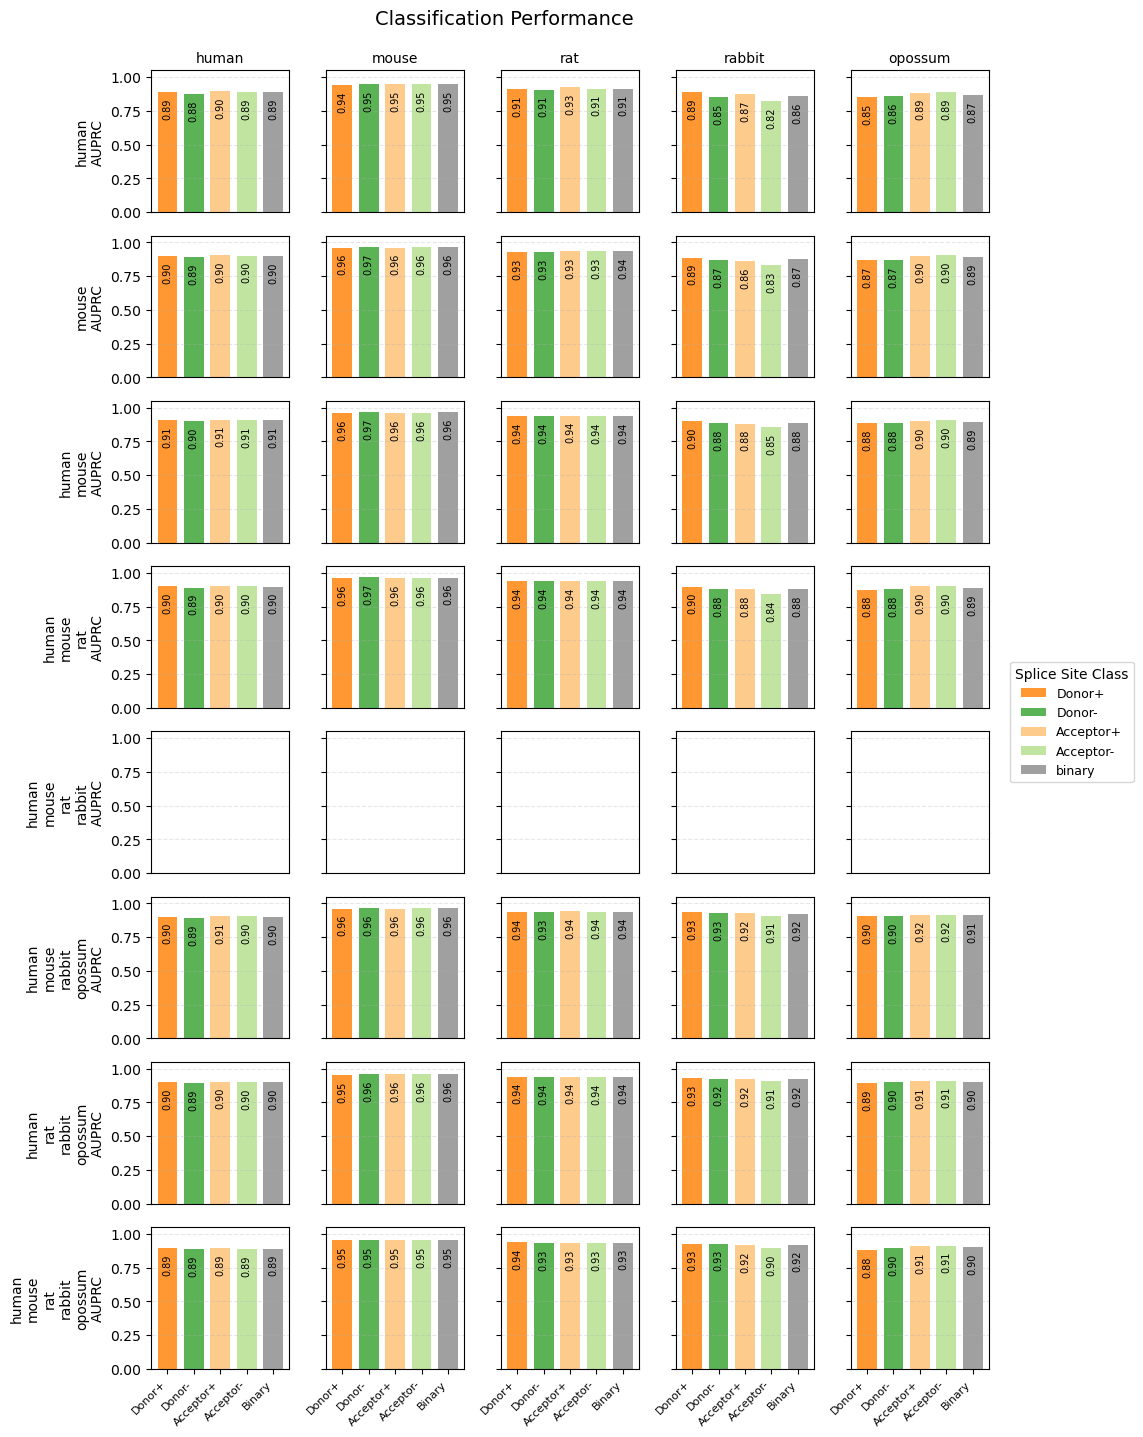

In [ ]:
# Grouped barplot: Classification AUPRC by class, organized in grid
# Rows = models, Columns = evaluation species
import matplotlib.pyplot as plt
import numpy as np

# Get unique models and prediction species
pred_species_list = sorted(df_classification['pred_species'].unique())
pred_species_list = [s for s in SPECIES_ORDER if s in pred_species_list]
classes = sorted(df_classification['class_idx'].unique())

n_models = len(models)
n_species = len(pred_species_list)
n_classes = len(classes)

# Create subplot grid: rows = models, cols = species
fig, axes = plt.subplots(n_models, n_species, figsize=(n_species * 2, n_models * 1.8),
                         squeeze=False, sharex=False, sharey=True)

bar_width = 0.25
x = np.arange(n_classes)

# Plot each model × species combination
for model_idx, model in enumerate(models):
    for species_idx, pred_sps in enumerate(pred_species_list):
        ax = axes[model_idx, species_idx]

        # Filter data for this model and species
        subset = df_classification[
            (df_classification['model'] == model) &
            (df_classification['pred_species'] == pred_sps)
        ]

        if len(subset) > 0:
            # Plot bars for each class
            for i, class_idx in enumerate(classes):
                class_data = subset[subset['class_idx'] == class_idx]

                if len(class_data) > 0:
                    auprc_value = class_data['auprc'].values[0]

                    # Use class colors
                    color = CLASS_COLORS.get(class_idx, '#888888')
                    label = CLASS_LABELS.get(class_idx, f'class_{class_idx}')
                    if class_idx == 4:  # Binary
                        label = 'binary'
                        color = '#888888'

                    bar = ax.bar(i, auprc_value, bar_width * 3, color=color, alpha=0.8,
                          label=label if model_idx == 0 and species_idx == 0 else "")

                    # Add value on top of bar
                    ax.text(i, auprc_value - 0.2, f'{auprc_value:.2f}',
                            ha='center', va='bottom', fontsize=7, rotation=90)

        # Customize subplot
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Set title for top row (species names)
        if model_idx == 0:
            ax.set_title(pred_sps, fontsize=10)

        # Set ylabel for leftmost column (model names)
        if species_idx == 0:
            # Split model name for better display
            model_display_name = model.replace('_', '+')
            model_display_name = '\n'.join(model_display_name.split('+'))
            ax.set_ylabel(f'{model_display_name}\nAUPRC', fontsize=10)

        # Only show x-ticks on bottom row
        if model_idx == n_models - 1:
            ax.set_xticks(range(n_classes))
            ax.set_xticklabels([CLASS_LABELS.get(c, 'binary') for c in classes],
                              rotation=45, ha='right', fontsize=8)
        else:
            ax.set_xticks([])

# Add overall title
fig.suptitle('Classification Performance', fontsize=14, y=0.995)

# Create legend (only once, outside subplots)
handles = []
labels = []
for class_idx in classes:
    color = CLASS_COLORS.get(class_idx, '#888888')
    label = CLASS_LABELS.get(class_idx, f'class_{class_idx}')
    if class_idx == 4:
        label = 'binary'
        color = '#888888'
    handles.append(plt.Rectangle((0,0),1,1, fc=color, alpha=0.8))
    labels.append(label)

fig.legend(handles, labels, title='Splice Site Class',
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)

plt.tight_layout()
plt.show()


Plot all models per class.

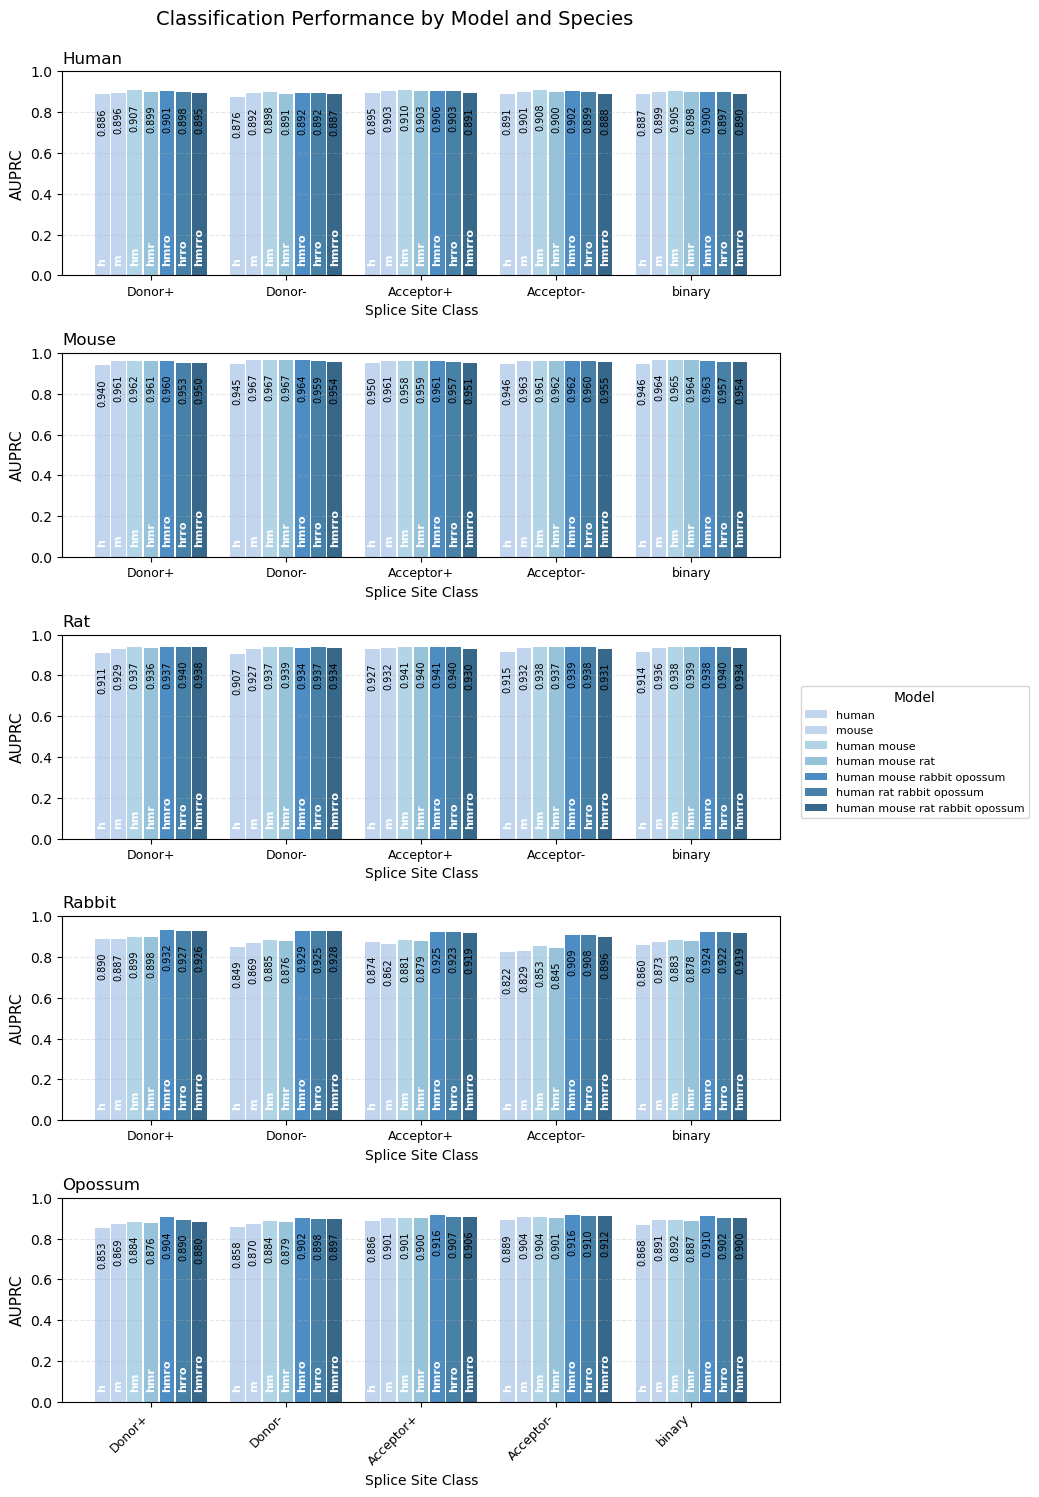

In [ ]:
# Grouped barplot: classes grouped by model, one plot per species
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Subset those models for which we have data
models_classification = [model for model in models if model in df_classification['model'].unique()]

# Get unique prediction species and classes
pred_species_list = [s for s in SPECIES_ORDER if s in df_classification['pred_species'].unique()]
classes = sorted(df_classification['class_idx'].unique())
n_classes = len(classes)
n_species = len(pred_species_list)

# Create subplots: one row per prediction species
fig, axes = plt.subplots(n_species, 1, figsize=(8, n_species * 3), squeeze=False)
axes = axes.flatten()

for species_idx, pred_sps in enumerate(pred_species_list):
    ax = axes[species_idx]
    
    # Filter data for this species
    species_data = df_classification[df_classification['pred_species'] == pred_sps]
    
    # Get models present for this species, in the defined order
    models_present = [m for m in models_classification if m in species_data['model'].unique()]
    n_models = len(models_present)
    
    # Spacing parameters
    bar_width = 0.12
    class_spacing = 1.0
    
    for model_idx, model in enumerate(models_present):
        model_data = species_data[species_data['model'] == model]
        color = MODEL_COLORS[model]
        
        for class_idx, cls in enumerate(classes):
            class_data = model_data[model_data['class_idx'] == cls]
            
            if len(class_data) > 0:
                auprc_value = class_data['auprc'].values[0]
                
                # Position: class group + model offset within group
                x_pos = class_idx * class_spacing + model_idx * bar_width
                
                ax.bar(x_pos, auprc_value, bar_width * 0.9, 
                       color=color, alpha=0.8,
                       label=model.replace('_', ' ') if class_idx == 0 else "")
                
                # Add value on top
                if auprc_value > 0.5:  # Only show if high enough
                    ax.text(x_pos, auprc_value - 0.2, f'{auprc_value:.3f}',
                            ha='center', va='bottom', fontsize=7, rotation=90)
                    
                # Add rotated model letter code near the bottom of each bar
                letter = MODEL_LETTERS.get(model, model[:2])  # Fallback to first 2 letters
                ax.text(
                    x_pos, 
                    0.05, 
                    letter, 
                    ha='center', 
                    va='bottom', 
                    rotation=90, 
                    fontsize=8, 
                    fontweight='bold', 
                    color='white'  # Change to 'black' if bar colors are light
                )

    
    # Customize subplot
    ax.set_ylim(0, 1)
    ax.set_ylabel('AUPRC', fontsize=11)
    ax.set_title(f'{pred_sps.capitalize()}', fontsize=12, loc='left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Set x-ticks at the center of each class group
    tick_positions = [class_idx * class_spacing + (n_models * bar_width) / 2 - bar_width/2 
                     for class_idx in range(n_classes)]
    ax.set_xticks(tick_positions)
    
    # Create class labels
    class_labels = []
    for cls in classes:
        label = CLASS_LABELS.get(cls, f'class_{cls}')
        if cls == 4:
            label = 'binary'
        class_labels.append(label)
    
    if species_idx == n_species - 1:
        ax.set_xticklabels(class_labels, rotation=45, ha='right', fontsize=9)
    else:
        ax.set_xticklabels(class_labels, fontsize=9)
    ax.set_xlabel('Splice Site Class', fontsize=10)

fig.suptitle('Classification Performance by Model and Species', fontsize=14, y=0.995)

# Create model legend with colors
legend_handles = []
for model in models_classification:
    color = MODEL_COLORS[model]
    legend_handles.append(Patch(facecolor=color, alpha=0.8, label=model.replace('_', ' ')))

fig.legend(handles=legend_handles, title='Model',
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

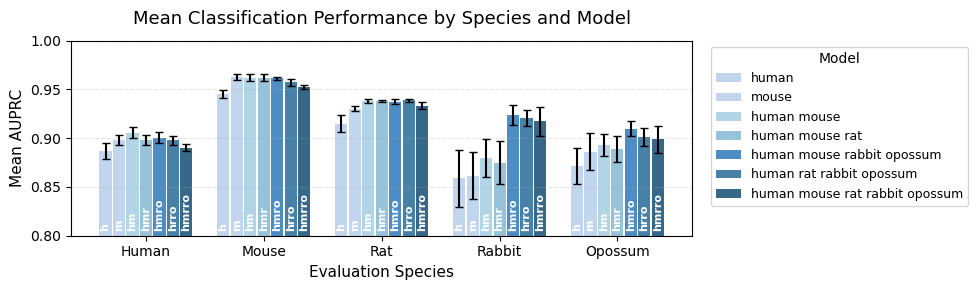

In [ ]:
# Subset models present in data
models_classification = [model for model in models if model in df_classification['model'].unique()]
pred_species_list = [s for s in SPECIES_ORDER if s in df_classification['pred_species'].unique()]

n_species = len(pred_species_list)
n_models = len(models_classification)

# Layout setup
species_indices = np.arange(n_species)
total_group_width = 0.8
bar_width = total_group_width / n_models

fig, ax = plt.subplots(figsize=(10, 3))

for model_idx, model in enumerate(models_classification):
    means = []
    errors = []  # Standard deviation
    
    for species in pred_species_list:
        sub_df = df_classification[
            (df_classification['pred_species'] == species) & 
            (df_classification['model'] == model) &
            (df_classification['class_idx'] != 4)  # exclude binary class
        ]
        
        if len(sub_df) > 0:
            means.append(sub_df['auprc'].mean())
            errors.append(sub_df['auprc'].std())  
        else:
            means.append(np.nan)
            errors.append(np.nan)
            
    # Center the model bars within each species group
    offset = (model_idx - (n_models - 1) / 2) * bar_width
    x_positions = species_indices + offset
    color = MODEL_COLORS[model]
    
    # Plot bars
    ax.bar(
        x_positions, 
        means, 
        yerr=errors, 
        width=bar_width * 0.9, 
        color=color, 
        alpha=0.8, 
        capsize=3,
        label=model.replace('_', ' ')
    )
    
    # Add rotated model letter code near the bottom of each bar
    letter = MODEL_LETTERS.get(model, model[:2])  # Fallback to first 2 letters
    for x_pos, mean_val in zip(x_positions, means):
        if not np.isnan(mean_val):
            ax.text(
                x_pos, 
                0.805, 
                letter, 
                ha='center', 
                va='bottom', 
                rotation=90, 
                fontsize=8, 
                fontweight='bold', 
                color='white'  # Change to 'black' if bar colors are light
            )

# Customize plot axes and aesthetics
ax.set_ylim(0.8, 1.0)
ax.set_ylabel('Mean AUPRC', fontsize=11)
ax.set_xlabel('Evaluation Species', fontsize=11)
ax.set_title('Mean Classification Performance by Species and Model', fontsize=13, pad=12)

# Set x-ticks to species names
ax.set_xticks(species_indices)
ax.set_xticklabels([s.capitalize() for s in pred_species_list], fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Legend
ax.legend(title='Model', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

Dfference relative to the human model baseline.

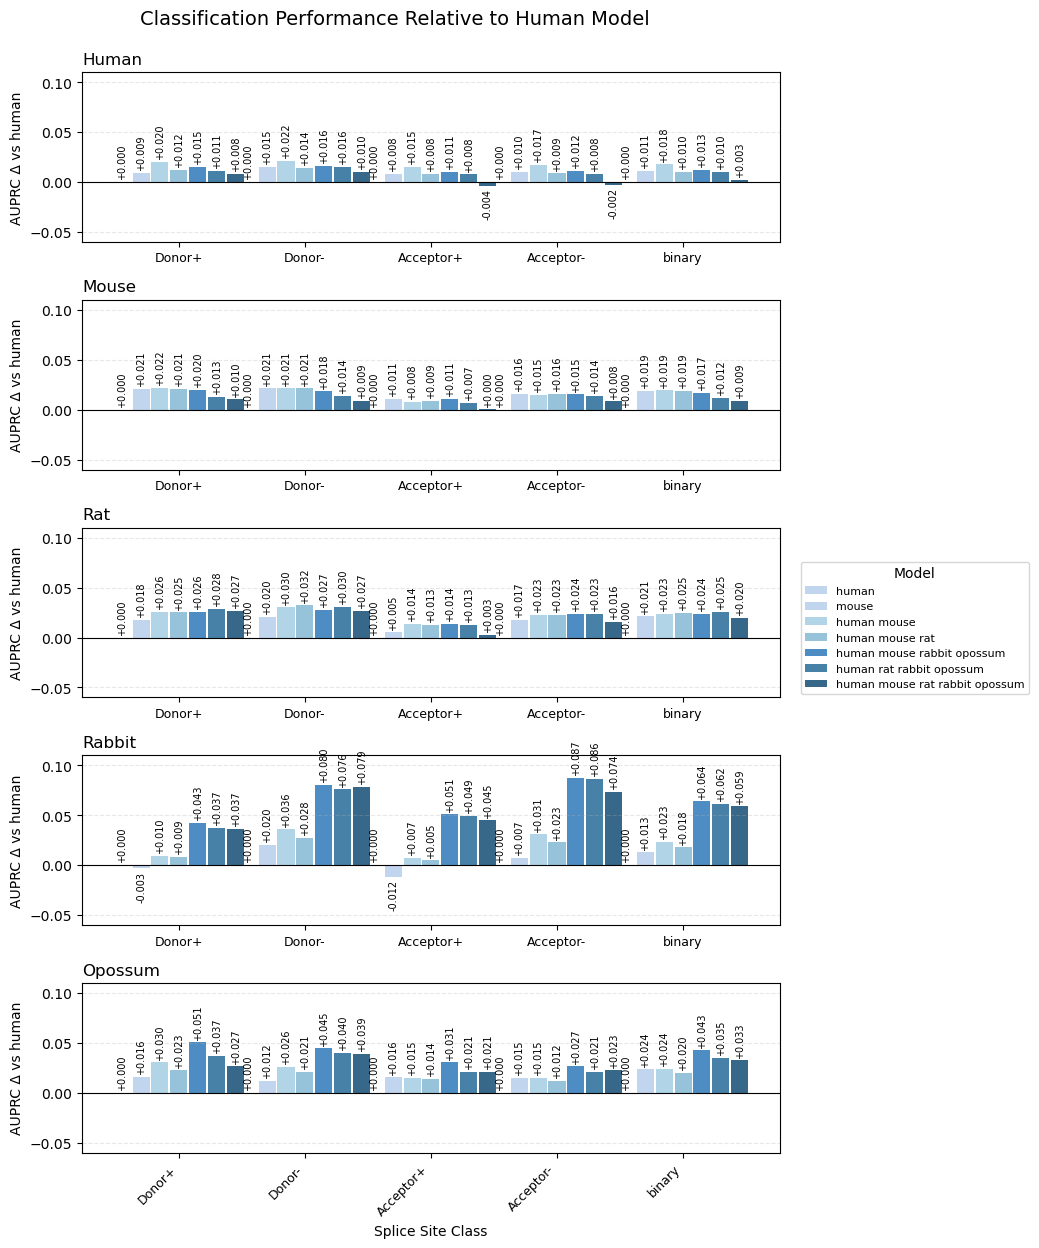

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

BASELINE_MODEL = 'human'

# Subset those models for which we have data
models_classification = [model for model in models if model in df_classification['model'].unique()]

# Get unique prediction species and classes
pred_species_list = [s for s in SPECIES_ORDER if s in df_classification['pred_species'].unique()]
classes = sorted(df_classification['class_idx'].unique())
n_classes = len(classes)
n_species = len(pred_species_list)

# Create subplots: one row per prediction species
fig, axes = plt.subplots(n_species, 1, figsize=(8, n_species * 2.5), squeeze=False)
axes = axes.flatten()

for species_idx, pred_sps in enumerate(pred_species_list):
    ax = axes[species_idx]

    # Filter data for this species
    species_data = df_classification[df_classification['pred_species'] == pred_sps]

    # Get models present for this species, in the defined order
    models_present = [m for m in models_classification if m in species_data['model'].unique()]
    n_models = len(models_present)

    # Get baseline AUPRC per class for this species
    baseline_data = species_data[species_data['model'] == BASELINE_MODEL]
    baseline_by_class = {
        cls: baseline_data[baseline_data['class_idx'] == cls]['auprc'].values[0]
        for cls in classes
        if len(baseline_data[baseline_data['class_idx'] == cls]) > 0
    }

    # Spacing parameters
    bar_width = 0.15
    class_spacing = 1.0

    for model_idx, model in enumerate(models_present):
        model_data = species_data[species_data['model'] == model]
        color = MODEL_COLORS[model]

        for class_idx, cls in enumerate(classes):
            class_data = model_data[model_data['class_idx'] == cls]
            if len(class_data) > 0 and cls in baseline_by_class:
                auprc_value = class_data['auprc'].values[0]
                diff_value = auprc_value - baseline_by_class[cls]

                # Position: class group + model offset within group
                x_pos = class_idx * class_spacing + model_idx * bar_width

                ax.bar(x_pos, diff_value, bar_width * 0.9,
                       color=color, alpha=0.8,
                       label=model.replace('_', ' ') if class_idx == 0 else "")

                # Add value label above/below bar depending on sign
                va = 'bottom' if diff_value >= 0 else 'top'
                offset = 0.0025 if diff_value >= 0 else -0.0025
                ax.text(x_pos, diff_value + offset, f'{diff_value:+.3f}',
                        ha='center', va=va, fontsize=7, rotation=90)

    # Customize subplot
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel(f'AUPRC Δ vs {BASELINE_MODEL}', fontsize=10)
    ax.set_title(f'{pred_sps.capitalize()}', fontsize=12, loc='left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Set x-ticks at the center of each class group
    tick_positions = [class_idx * class_spacing + (n_models * bar_width) / 2 - bar_width/2
                       for class_idx in range(n_classes)]
    ax.set_xticks(tick_positions)

    # Create class labels
    class_labels = []
    for cls in classes:
        label = CLASS_LABELS.get(cls, f'class_{cls}')
        if cls == 4:
            label = 'binary'
        class_labels.append(label)

    if species_idx == n_species - 1:
        ax.set_xticklabels(class_labels, rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('Splice Site Class', fontsize=10)
    else:
        ax.set_xticklabels(class_labels, fontsize=9)

    ax.set_ylim(-0.06, 0.11)

fig.suptitle(f'Classification Performance Relative to {BASELINE_MODEL.capitalize()} Model', fontsize=14, y=0.995)

# Create model legend with colors
legend_handles = []
for model in models_classification:
    color = MODEL_COLORS[model]
    legend_handles.append(Patch(facecolor=color, alpha=0.8, label=model.replace('_', ' ')))
fig.legend(handles=legend_handles, title='Model',
           loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

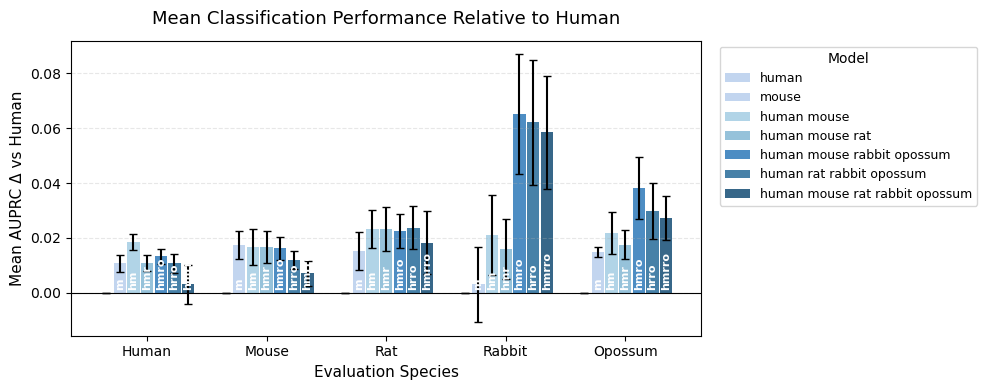

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

BASELINE_MODEL = 'human'

# Subset models present in data
models_classification = [model for model in models if model in df_classification['model'].unique()]
pred_species_list = [s for s in SPECIES_ORDER if s in df_classification['pred_species'].unique()]

n_species = len(pred_species_list)
n_models = len(models_classification)

# Layout setup
species_indices = np.arange(n_species)
total_group_width = 0.8
bar_width = total_group_width / n_models

fig, ax = plt.subplots(figsize=(10, 4))

for model_idx, model in enumerate(models_classification):
    means = []
    errors = []  # Standard deviation across classes
    
    for species in pred_species_list:
        sub_df = df_classification[
            (df_classification['pred_species'] == species)
        ]
        
        # Calculate class-wise differences relative to baseline for this species
        baseline_df = sub_df[sub_df['model'] == BASELINE_MODEL]
        model_df = sub_df[sub_df['model'] == model]
        
        # Merge on class_idx to compute delta per class
        merged = model_df.merge(baseline_df, on='class_idx', suffixes=('', '_base'))
        merged = merged[merged['class_idx'] != 4]  # Exclude binary class
        diffs = merged['auprc'] - merged['auprc_base']
        
        if len(diffs) > 0:
            means.append(diffs.mean())
            errors.append(diffs.std())
        else:
            means.append(np.nan)
            errors.append(np.nan)
            
    # Center the model bars within each species group
    offset = (model_idx - (n_models - 1) / 2) * bar_width
    x_positions = species_indices + offset
    color = MODEL_COLORS[model]
    
    # Plot bars
    ax.bar(
        x_positions, 
        means, 
        yerr=errors, 
        width=bar_width * 0.9, 
        color=color, 
        alpha=0.8, 
        capsize=3,
        label=model.replace('_', ' ')
    )
    
    # Add rotated model letter code near the bottom of each bar (just above y=0)
    letter = MODEL_LETTERS.get(model, model[:2])
    
    for x_pos, mean_val in zip(x_positions, means):
        if not np.isnan(mean_val):
            ax.text(
                x_pos, 
                0.001,  # Positioned right above y=0 line
                letter, 
                ha='center', 
                va='bottom', 
                rotation=90, 
                fontsize=8, 
                fontweight='bold', 
                color='white'  # Change to 'black' if bar colors are light
            )

# Customize plot axes and aesthetics
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel(f'Mean AUPRC Δ vs {BASELINE_MODEL.capitalize()}', fontsize=11)
ax.set_xlabel('Evaluation Species', fontsize=11)
ax.set_title(f'Mean Classification Performance Relative to {BASELINE_MODEL.capitalize()}', fontsize=13, pad=12)

# Set x-ticks to species names
ax.set_xticks(species_indices)
ax.set_xticklabels([s.capitalize() for s in pred_species_list], fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Legend
ax.legend(title='Model', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

<>:73: SyntaxWarning: invalid escape sequence '\D'
<>:73: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_420646/3440613055.py:73: SyntaxWarning: invalid escape sequence '\D'
  delta_str = f"$\Delta$ AUPRC = {delta*100:+.1f}%"


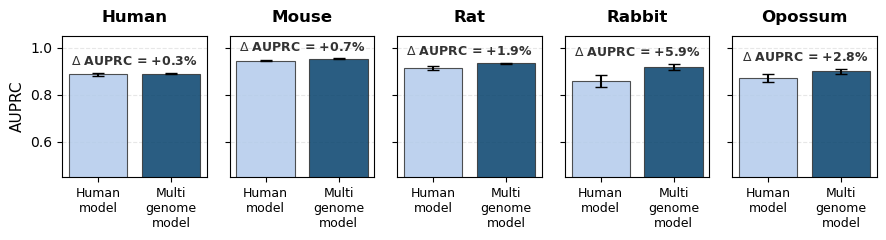

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Define target models to isolate ---
SINGLE_SPECIES_MODEL = 'human'
MULTI_SPECIES_MODEL = 'human_mouse_rat_rabbit_opossum'
TARGET_MODELS = [SINGLE_SPECIES_MODEL, MULTI_SPECIES_MODEL]

# Subset models and species present in data
models_usage = [model for model in TARGET_MODELS if model in df_classification['model'].unique()]
pred_species_list = [s for s in SPECIES_ORDER if s in df_classification['pred_species'].unique()]

n_species = len(pred_species_list)

# --- Grid Setup ---
# 1 row with n_species columns (adjust ncols/nrows if you have many species)
ncols = n_species
nrows = 1
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(1.8 * ncols, 2.5), sharey=True)

# Ensure axes is iterable even if there's only 1 species
if n_species == 1:
    axes = [axes]

x_positions = [0, 1]
x_labels = [f'{SINGLE_SPECIES_MODEL.capitalize()}\nmodel', 'Multi\ngenome\nmodel']
bar_width = 0.8

for sp_idx, species in enumerate(pred_species_list):
    ax = axes[sp_idx]
    
    means = []
    errors = []
    
    for model in models_usage:
        sub_df = df_classification[
            (df_classification['pred_species'] == species) & 
            (df_classification['model'] == model)
        ]
        
        if len(sub_df) > 0:
            auprc_pooled = sub_df['auprc']
            means.append(auprc_pooled.mean())
            errors.append(auprc_pooled.std())  
        else:
            means.append(np.nan)
            errors.append(np.nan)
            
    # Plot bars for the two models
    colors = [MODEL_COLORS.get(m, '#575656') for m in models_usage]
    
    bars = ax.bar(
        x_positions, 
        means, 
        yerr=errors, 
        width=bar_width, 
        color=colors, 
        alpha=0.85, 
        capsize=4,
        edgecolor='#333333',
        linewidth=0.8
    )
    
    # --- Compute & Display Delta AUPRC ---
    if len(means) == 2 and not np.isnan(means[0]) and not np.isnan(means[1]):
        s_mean, m_mean = means[0], means[1]
        s_err = errors[0] if not np.isnan(errors[0]) else 0
        m_err = errors[1] if not np.isnan(errors[1]) else 0
        
        delta = m_mean - s_mean
        max_height = max(s_mean + s_err, m_mean + m_err)
        
        delta_str = f"$\Delta$ AUPRC = {delta*100:+.1f}%"
        
        # Center delta text above the panel's two bars
        ax.text(
            0.5, 
            max_height + 0.02, 
            delta_str, 
            ha='center', 
            va='bottom', 
            fontsize=9, 
            fontweight='bold', 
            color='#333333'
        )

    # --- Subplot Aesthetics ---
    ax.set_ylim(0.45, 1.05)
    ax.set_title(species.capitalize(), fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Y-axis label only on the leftmost plot
    if sp_idx == 0:
        ax.set_ylabel('AUPRC', fontsize=11)

plt.tight_layout()
plt.show()

## Splice usage metrics (per-condition correlations)

In [7]:
# Extract per-condition usage correlations from saved predictions
# We'll compute correlations from the usage .npz files and map to tissues via metadata

from scipy.stats import pearsonr
from pathlib import Path

def get_pooled_r(metrics_entry, pred_sps, usage_head_species):
    """Look up the pooled Pearson r for a given species/head from metrics dict entry.
    usage_by_head keys may be either the bare species name ("human") or
    prefixed with "from_" ("from_human"), so we try both.
    """
    species_m = metrics_entry.get(pred_sps, {})
    by_head = species_m.get('usage_by_head', {})
    if by_head:
        # Try bare name first, then "from_<name>"
        for key in (usage_head_species, f"from_{usage_head_species}"):
            val = by_head.get(key, {}).get('usage_pearson_r')
            if val is not None:
                return val
        return None
    return species_m.get('usage_pearson_r', None)

usage_data_list = []

verbose = True  # Set to True to print debug info

for (model, preds_path, pred_sps), metrics in metrics_dict.items():

    pred_dir = Path(f"{preds_path}/{pred_sps}")
    
    # Load usage metadata to map conditions to tissues
    species_map = {'human': 'Homo_sapiens', 'mouse': 'Mus_musculus', 'rat': 'Rattus_norvegicus', 'rabbit': 'Oryctolagus_cuniculus', 'opossum': 'Monodelphis_domestica'}
    metadata_path = Path(f"{base_dir}/data/{species_map[pred_sps]}/usage.json")
    
    if not metadata_path.exists():
        print(f"Metadata not found: {metadata_path}")
        continue
    
    with open(metadata_path) as f:
        usage_metadata = json.load(f)
    condition_labels = usage_metadata.get("condition_labels", {})
    idx_to_name = {int(v): k for k, v in condition_labels.items()}
    
    # Build usage_files list fully before iterating
    usage_files = []
    for model_sps in model.split('_'):
        if model_sps != pred_sps:
            candidate = (f"usage_{pred_sps}_from_{model_sps}.npz", model_sps)
            if candidate not in usage_files:
                usage_files.append(candidate)
        else:
            candidate = (f"usage_{pred_sps}.npz", model_sps)
            if candidate not in usage_files:
                usage_files.append(candidate)

    for usage_file, usage_head_species in usage_files:
        usage_path = pred_dir / usage_file
        
        if not usage_path.exists():
            print(f"Usage file not found: {usage_path}")
            continue

        if verbose:
            print(f"model={model}, pred_species={pred_sps}, usage_head_species={usage_head_species}")

        pooled_r = get_pooled_r(metrics, pred_sps, usage_head_species)
        usage_data = np.load(usage_path)
        
        # Compute per-condition correlations using summary statistics
        stats_cond_ids = usage_data['stats_cond_ids']
        stats_n = usage_data['stats_n']
        stats_sum_pred = usage_data['stats_sum_pred']
        stats_sum_true = usage_data['stats_sum_true']
        stats_sum_pred2 = usage_data['stats_sum_pred2']
        stats_sum_true2 = usage_data['stats_sum_true2']
        stats_sum_prod = usage_data['stats_sum_prod']
        
        for i, cond_idx in enumerate(stats_cond_ids):
            n = stats_n[i]
            if n <= 1:
                continue
            
            # Pearson r from summary statistics
            numerator = n * stats_sum_prod[i] - stats_sum_pred[i] * stats_sum_true[i]
            denom_pred = n * stats_sum_pred2[i] - stats_sum_pred[i] ** 2
            denom_true = n * stats_sum_true2[i] - stats_sum_true[i] ** 2
            
            if denom_pred > 0 and denom_true > 0:
                r = numerator / np.sqrt(denom_pred * denom_true)
            else:
                continue
            
            # Get condition name and extract tissue
            cond_name = idx_to_name.get(int(cond_idx), f"unknown_{cond_idx}")
            tissue = cond_name.rsplit('_', 1)[0] if '_' in cond_name else cond_name
            
            try:
                timepoint = int(cond_name.rsplit('_', 1)[1]) if '_' in cond_name else None
            except:
                timepoint = None

            usage_data_list.append({
                'model': model,
                'model_species': usage_head_species,
                'pred_species': pred_sps,
                'tissue': tissue,
                'condition_idx': int(cond_idx),
                'condition_name': cond_name,
                'timepoint': timepoint,
                'correlation': float(r),
                'pooled_r': float(pooled_r) if pooled_r is not None else float('nan'),
                'n': int(n)
            })

df_usage_ = pd.DataFrame(usage_data_list)
print(f"Extracted {len(df_usage_)} per-condition usage correlations")
df_usage_

model=human, pred_species=human, usage_head_species=human
model=human, pred_species=mouse, usage_head_species=human
model=human, pred_species=rat, usage_head_species=human
model=human, pred_species=rabbit, usage_head_species=human
model=human, pred_species=opossum, usage_head_species=human
model=mouse, pred_species=human, usage_head_species=mouse
model=mouse, pred_species=mouse, usage_head_species=mouse
model=mouse, pred_species=rat, usage_head_species=mouse
model=mouse, pred_species=rabbit, usage_head_species=mouse
model=mouse, pred_species=opossum, usage_head_species=mouse
model=human_mouse, pred_species=human, usage_head_species=human
model=human_mouse, pred_species=human, usage_head_species=mouse
model=human_mouse, pred_species=mouse, usage_head_species=human
model=human_mouse, pred_species=mouse, usage_head_species=mouse
model=human_mouse, pred_species=rat, usage_head_species=human
model=human_mouse, pred_species=rat, usage_head_species=mouse
model=human_mouse, pred_species=rabbit

,model,model_species,pred_species,tissue,condition_idx,condition_name,timepoint,correlation,pooled_r,n
0,human,human,human,Brain,0,Brain_1,1,0.856703,0.843450,16673
1,human,human,human,Brain,1,Brain_10,10,0.867471,0.843450,15061
2,human,human,human,Brain,2,Brain_11,11,0.862551,0.843450,13192
3,human,human,human,Brain,3,Brain_12,12,0.819114,0.843450,14885
4,human,human,human,Brain,4,Brain_13,13,0.848172,0.843450,14926
...,...,...,...,...,...,...,...,...,...,...
4583,human_mouse_rat_rabbit_opossum,rabbit,rabbit,Testis,87,Testis_5,5,0.647033,0.752111,12120
4584,human_mouse_rat_rabbit_opossum,rabbit,rabbit,Testis,88,Testis_6,6,0.678418,0.752111,12027
4585,human_mouse_rat_rabbit_opossum,rabbit,rabbit,Testis,89,Testis_7,7,0.678270,0.752111,11715
4586,human_mouse_rat_rabbit_opossum,rabbit,rabbit,Testis,90,Testis_8,8,0.705971,0.752111,11403


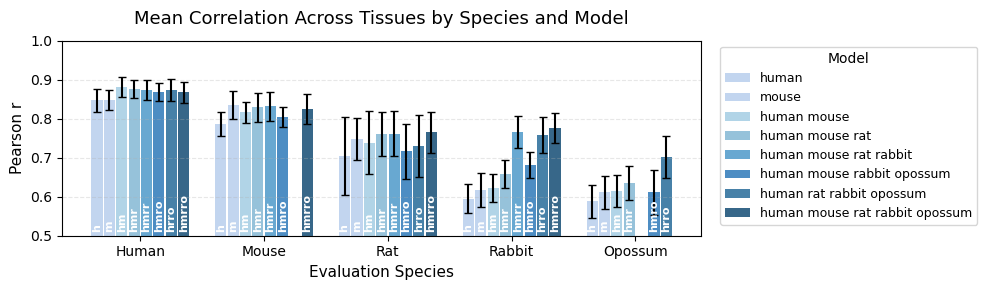

In [8]:
# Subset models and species present in data
models_usage = [model for model in models if model in df_usage_['model'].unique()]
pred_species_list = [s for s in SPECIES_ORDER if s in df_usage_['pred_species'].unique()]

n_species = len(pred_species_list)
n_models = len(models_usage)

# Layout setup
species_indices = np.arange(n_species)
total_group_width = 0.8
bar_width = total_group_width / n_models

fig, ax = plt.subplots(figsize=(10, 3))

for model_idx, model in enumerate(models_usage):
    means = []
    errors = []  # Standard deviation across tissues
    
    for species in pred_species_list:
        sub_df = df_usage_[
            (df_usage_['pred_species'] == species) & 
            (df_usage_['model'] == model)
        ]
        
        if len(sub_df) > 0:
            # Group by tissue to get unique pooled_r value per tissue
            tissue_pooled = sub_df.groupby('tissue')['correlation'].first()
            means.append(tissue_pooled.mean())
            errors.append(tissue_pooled.std())  
        else:
            means.append(np.nan)
            errors.append(np.nan)
            
    # Center the model bars within each species group
    offset = (model_idx - (n_models - 1) / 2) * bar_width
    x_positions = species_indices + offset
    color = MODEL_COLORS[model]
    
    # Plot bars
    ax.bar(
        x_positions, 
        means, 
        yerr=errors, 
        width=bar_width * 0.9, 
        color=color, 
        alpha=0.8, 
        capsize=3,
        label=model.replace('_', ' ')
    )
    
    # Add rotated model letter code near the bottom of each bar
    letter = MODEL_LETTERS.get(model)
    
    for x_pos, mean_val in zip(x_positions, means):
        if not np.isnan(mean_val):
            # Positioned just above the y=0 line
            ax.text(
                x_pos, 
                0.51, 
                letter, 
                ha='center', 
                va='bottom', 
                rotation=90, 
                fontsize=8, 
                fontweight='bold', 
                color='white'  # Change to 'black' if bar fill is light
            )

# Customize plot axes and aesthetics
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Pearson r', fontsize=11)
ax.set_xlabel('Evaluation Species', fontsize=11)
ax.set_title('Mean Correlation Across Tissues by Species and Model', fontsize=13, pad=12)

# Set x-ticks to species names
ax.set_xticks(species_indices)
ax.set_xticklabels([s.capitalize() for s in pred_species_list], fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Legend
ax.legend(title='Model', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

#### Human vs multi species model

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. New Colors ---
NEW_MODEL_COLORS = {
    "human": "#b3cbeb",
    "mouse": "#b3cbeb",
    "human_mouse": "#165B8D",
    "human_mouse_rat_rabbit_opossum": "#05416C"
}

# --- 2. Model Configuration ---
SINGLE_SPECIES_MODELS = ['human', 'mouse']
MULTI_SPECIES_MODELS = ['human_mouse', 'human_mouse_rat_rabbit_opossum']
TARGET_MODELS = SINGLE_SPECIES_MODELS + MULTI_SPECIES_MODELS

# --- 3. Evaluation Species Subset Argument ---
# Change this list to filter which target species panels to render
EVAL_SPECIES_SUBSET = ['human', 'mouse']

# Filter models and species present in dataframe
models_usage = [m for m in TARGET_MODELS if m in df_usage_['model'].unique()]
pred_species_list = [s for s in EVAL_SPECIES_SUBSET if s in df_usage_['pred_species'].unique()]

n_species = len(pred_species_list)
n_models = len(models_usage)

# Map colors directly using original MODEL_COLORS dictionary
colors = [NEW_MODEL_COLORS.get(m, '#575656') for m in models_usage]

# Text
FONT_SIZE = 12

# --- Helper Function: Bracket Renderer ---
def draw_bracket(ax, x1, x2, y, h, text, fontsize=FONT_SIZE):
    """Draws a comparison bracket between x1 and x2 at height y."""
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='#333333', lw=0.9)
    ax.text(
        (x1 + x2) * 0.5, 
        y + h + 0.005, 
        text, 
        ha='center', 
        va='bottom', 
        fontsize=fontsize, 
        fontweight='bold', 
        color='#333333'
    )


<>:118: SyntaxWarning: invalid escape sequence '\D'
<>:118: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1472167/2784812954.py:118: SyntaxWarning: invalid escape sequence '\D'
  delta_str = f"$\Delta r$={delta*100:+.1f}%"


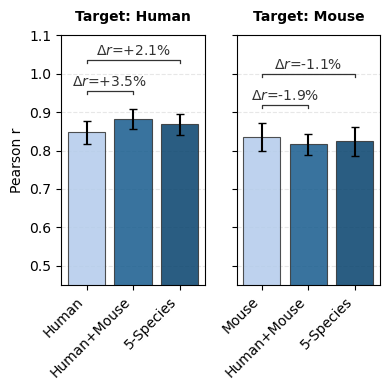

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- Define Unified Font Size ---
FONT_SIZE = 10

# --- Helper Function: Bracket Renderer ---
def draw_bracket(ax, x1, x2, y, h, text, fontsize=FONT_SIZE):
    """Draws a comparison bracket between x1 and x2 at height y."""
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='#333333', lw=0.9)
    ax.text(
        (x1 + x2) * 0.5, 
        y + h + 0.005, 
        text, 
        ha='center', 
        va='bottom', 
        fontsize=fontsize,  
        color='#333333'
    )

# --- Plot Setup ---
ncols = n_species
nrows = 1
# Dynamic width based on max models per panel
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(0.5 * n_models * ncols, 4.0), sharey=True)

if n_species == 1:
    axes = [axes]

x_label_map = {
    'human': 'Human',
    'mouse': 'Mouse',
    'human_mouse': 'Human+Mouse',
    'human_mouse_rat_rabbit_opossum': '5-Species'
}

bar_width = 0.8

# --- Main Plotting Loop ---
for sp_idx, species in enumerate(pred_species_list):
    ax = axes[sp_idx]
    
    # --- Species-specific Model Filtering ---
    # Filter out irrelevant single-species baseline depending on target species
    panel_models = [m for m in models_usage if not (
        (species == 'human' and m == 'mouse') or 
        (species == 'mouse' and m == 'human')
    )]
    
    NEW_MODEL_COLORS = {
        "human" : "#b3cbeb",
        "mouse" : "#b3cbeb",
        "human_mouse" : "#165B8D",
        "human_mouse_rat_rabbit_opossum" : "#05416C"
    }
    panel_colors = [NEW_MODEL_COLORS.get(m, '#575656') for m in panel_models]
    panel_x_pos = np.arange(len(panel_models))
    panel_x_labels = [x_label_map.get(m, m) for m in panel_models]
    
    means = []
    errors = []
    
    for model in panel_models:
        sub_df = df_usage_[
            (df_usage_['pred_species'] == species) & 
            (df_usage_['model'] == model)
        ]
        
        if len(sub_df) > 0:
            tissue_pooled = sub_df.groupby('tissue')['correlation'].first()
            means.append(tissue_pooled.mean())
            errors.append(tissue_pooled.std())  
        else:
            means.append(np.nan)
            errors.append(np.nan)
            
    # Draw bars for the species-specific model subset
    ax.bar(
        panel_x_pos, 
        means, 
        yerr=errors, 
        width=bar_width, 
        color=panel_colors, 
        alpha=0.85, 
        capsize=3,
        edgecolor='#333333',
        linewidth=0.8
    )
    
    # --- Bracket Annotations ---
    max_bar_peak = max([
        (m + (e if not np.isnan(e) else 0)) 
        for m, e in zip(means, errors) if not np.isnan(m)
    ] or [0.8])
    
    bracket_y_start = max_bar_peak + 0.04
    bracket_step = 0.08
    b_counter = 0

    # Ordered candidate comparisons
    all_comparison_pairs = [
        ('human', 'human_mouse'),
        ('human', 'human_mouse_rat_rabbit_opossum'),
        ('mouse', 'human_mouse'),
        ('mouse', 'human_mouse_rat_rabbit_opossum')
    ]

    # Filter comparisons to only those present in the current panel
    for single_m, multi_m in all_comparison_pairs:
        if single_m in panel_models and multi_m in panel_models:
            s_idx = panel_models.index(single_m)
            m_idx = panel_models.index(multi_m)
            
            s_mean, m_mean = means[s_idx], means[m_idx]
            
            if not np.isnan(s_mean) and not np.isnan(m_mean):
                delta = m_mean - s_mean
                delta_str = f"$\Delta r$={delta*100:+.1f}%"
                y_pos = bracket_y_start + (b_counter * bracket_step)
                
                draw_bracket(
                    ax, 
                    x1=panel_x_pos[s_idx], 
                    x2=panel_x_pos[m_idx], 
                    y=y_pos, 
                    h=0.008, 
                    text=delta_str,
                    fontsize=FONT_SIZE
                )
                b_counter += 1

    # --- Panel Styling ---
    y_upper_limit = bracket_y_start + (b_counter * bracket_step) + 0.03
    ax.set_ylim(0.45, max(1.09, y_upper_limit))
    ax.set_title(f"Target: {species.capitalize()}", fontsize=FONT_SIZE, fontweight='bold', pad=10)
    ax.set_xticks(panel_x_pos)
    ax.set_xticklabels(panel_x_labels, fontsize=FONT_SIZE, rotation=45, ha='right')
    ax.tick_params(axis='both', labelsize=FONT_SIZE)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    if sp_idx == 0:
        ax.set_ylabel('Pearson r', fontsize=FONT_SIZE)

plt.tight_layout()
plt.show()

#### Left-out species performance

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define vars - mouse
LEFTOUT_SPECIES = 'mouse'
BASELINE_SPECIES = ['human']
MODEL_WITH_LEFTOUT = 'human_mouse_rat_rabbit_opossum'
MODEL_WITHOUT_LEFTOUT = 'human_rat_rabbit_opossum'
USE_HEAD = 'rat'
TISSUES = [None, 'Liver', 'Cerebellum', 'Testis']

# Define vars - rat
LEFTOUT_SPECIES = 'rat'
BASELINE_SPECIES = ['human']
MODEL_WITH_LEFTOUT = 'human_mouse_rat'
MODEL_WITHOUT_LEFTOUT = 'human_mouse'
USE_HEAD = 'mouse'
TISSUES = [None, 'Liver', 'Cerebellum', 'Testis']

# Define vars - rat
LEFTOUT_SPECIES = 'rat'
BASELINE_SPECIES = ['human']
MODEL_WITH_LEFTOUT = 'human_mouse_rat_rabbit_opossum'
MODEL_WITHOUT_LEFTOUT = 'human_mouse_rabbit_opossum'
USE_HEAD = 'human'
TISSUES = [None, 'Liver', 'Cerebellum', 'Testis']

# Define vars - rabbit
LEFTOUT_SPECIES = 'rabbit'
BASELINE_SPECIES = ['human']
MODEL_WITH_LEFTOUT = 'human_mouse_rat_rabbit_opossum'
MODEL_WITHOUT_LEFTOUT = 'human_mouse_rat'
USE_HEAD = 'human'
TISSUES = [None, 'Liver', 'Cerebellum', 'Testis']

# Define EXACT ordering for x-axis (LEFTOUT_SPECIES can be placed ANYWHERE):
SPECIES_ORDER = ['human', 'rabbit']
SPECIES_ORDER = [s for s in SPECIES_ORDER if s in BASELINE_SPECIES + [LEFTOUT_SPECIES]]
TISSUES_ORDER = [None, 'Liver', 'Cerebellum', 'Testis']

# Helper function to compute mean & std of correlation across tissues
def get_species_stats(df, model_name, target_species, target_tissue=None, model_head=None):
    sub_df = df[(df['model'] == model_name) & (df['pred_species'] == target_species)]

    if model_head is None:
        if 'model_species' in sub_df.columns:
            sub_df = sub_df[sub_df['model_species'] == target_species]
    elif model_head != 'all':
        if 'model_species' in sub_df.columns:
            sub_df = sub_df[sub_df['model_species'] == model_head]

    if target_tissue is not None:
        sub_df = sub_df[sub_df['tissue'] == target_tissue]

    if len(sub_df) > 0:

        if target_tissue is not None:
            return sub_df['correlation'].mean(), sub_df['correlation'].std()
        
        tissue_corr = sub_df.groupby('tissue')['correlation'].mean()
        return tissue_corr.mean(), tissue_corr.std()
    
    return np.nan, np.nan 

v1

<>:97: SyntaxWarning: invalid escape sequence '\D'
<>:97: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1472167/518666462.py:97: SyntaxWarning: invalid escape sequence '\D'
  delta_str = f"$\Delta r$ = {delta*100:+.1f}%"


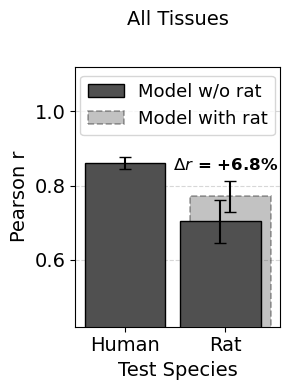

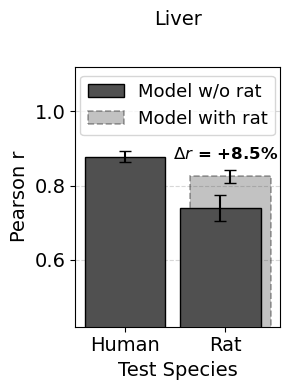

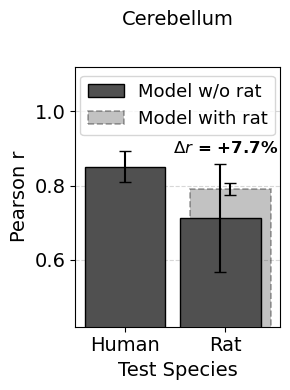

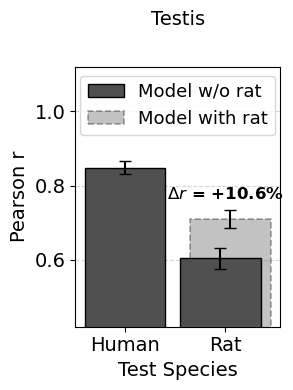

In [27]:
import matplotlib.pyplot as plt
import numpy as np

base_color = "#505050"
darker_ecolor = "#000000"

font_size = 14
bar_width = 0.8

for TISSUE in TISSUES_ORDER:
    # --- Compute performance values ---
    BASELINE_SPECIES_LIST = [BASELINE_SPECIES] if not isinstance(BASELINE_SPECIES, list) else BASELINE_SPECIES
    base_stats = [
        get_species_stats(df_usage_, MODEL_WITHOUT_LEFTOUT, target_species=sp, target_tissue=TISSUE, model_head=sp)
        for sp in BASELINE_SPECIES_LIST
    ]

    mean_wo_leftout, std_wo_leftout = get_species_stats(
        df_usage_, MODEL_WITHOUT_LEFTOUT, target_species=LEFTOUT_SPECIES, target_tissue=TISSUE, model_head=USE_HEAD
    )
    mean_w_leftout, std_w_leftout = get_species_stats(
        df_usage_, MODEL_WITH_LEFTOUT, target_species=LEFTOUT_SPECIES, target_tissue=TISSUE, model_head=LEFTOUT_SPECIES
    )

    # Calculate difference for the unseen species
    delta = mean_w_leftout - mean_wo_leftout

    # Setup x positions dynamically based on baseline count
    n_baselines = len(BASELINE_SPECIES_LIST)
    x_positions = list(range(n_baselines + 1))

    # Dynamically adjust figure width
    fig_width = max(3, 1.1 * len(x_positions))
    fig, ax = plt.subplots(figsize=(fig_width, 4))


    # --- Bars 1 to N: Baseline Species ---
    for i, (mean_val, std_val) in enumerate(base_stats):
        ax.bar(
            x_positions[i],
            mean_val,
            yerr=std_val,
            width=bar_width,
            color=base_color,
            ecolor=darker_ecolor,
            edgecolor=darker_ecolor,
            linewidth=1.0,
            alpha=1.0,
            capsize=4,
            label=f'Model w/o {LEFTOUT_SPECIES}' if i == 0 else None
        )
        

    # Left-out species position
    leftout_x = x_positions[-1]

    # --- Bar N+1 (BEHIND / SHIFTED RIGHT): Model WITH left-out species ---
    bg_offset = 0.05
    ax.bar(
        leftout_x + bg_offset,
        mean_w_leftout,
        yerr=std_w_leftout,
        width=bar_width,
        color=base_color,
        ecolor=darker_ecolor,
        edgecolor=darker_ecolor,
        linestyle='--',
        linewidth=1.2,
        alpha=0.35,
        capsize=4,
        zorder=2,
        label=f'Model with {LEFTOUT_SPECIES}'
    )

    # --- Bar N+2 (IN FRONT / SHIFTED LEFT): Model WITHOUT left-out species ---
    fg_offset = -0.05
    ax.bar(
        leftout_x + fg_offset,
        mean_wo_leftout,
        yerr=std_wo_leftout,
        width=bar_width,
        color=base_color,
        ecolor=darker_ecolor,
        edgecolor=darker_ecolor,
        linewidth=1.0,
        alpha=1.0,
        capsize=4,
        zorder=3
    )

    # Text above the left-out species bar plot showing delta
    if not np.isnan(delta):
        max_height = max(
            mean_w_leftout + (std_w_leftout if not np.isnan(std_w_leftout) else 0),
            mean_wo_leftout + (std_wo_leftout if not np.isnan(std_wo_leftout) else 0)
        )
        delta_str = f"$\Delta r$ = {delta*100:+.1f}%"
        ax.text(
            leftout_x,
            max_height + 0.02,
            delta_str,
            ha='center',
            va='bottom',
            color=darker_ecolor,
            fontsize=font_size - 2,
            fontweight='bold'
        )

    # --- Aesthetics and Styling ---
    ax.set_ylim(0.42, 1.12)
    ax.set_ylabel('Pearson r', fontsize=font_size)
    ax.set_xlabel('Test Species', fontsize=font_size)

    # Set x-ticks dynamically for all baselines + left-out species
    xtick_labels = [sp.capitalize() for sp in BASELINE_SPECIES_LIST] + [LEFTOUT_SPECIES.capitalize()]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(xtick_labels, fontsize=font_size)

    # Tick params
    ax.tick_params(axis='y', labelsize=font_size)

    ax.grid(axis='y', alpha=0.5, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(loc='upper right', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=font_size - 1)

    title_str = TISSUE if TISSUE else 'All Tissues'
    ax.set_title(title_str, fontsize=font_size, pad=30)

    plt.tight_layout()
    plt.show()

v2

<>:77: SyntaxWarning: invalid escape sequence '\D'
<>:77: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1472167/1541555295.py:77: SyntaxWarning: invalid escape sequence '\D'
  delta_str = f"$\Delta r$={delta*100:.1f}%"


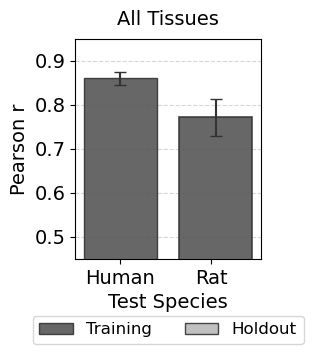

[All Tissues] Model w/o rat: nan ± nan
[All Tissues] Model w/ rat: 0.7717 ± 0.0417


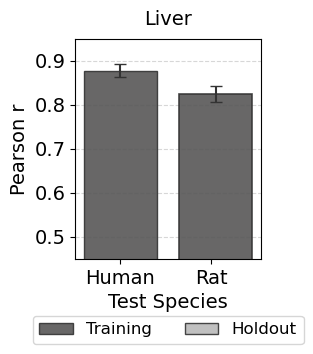

[Liver] Model w/o rat: nan ± nan
[Liver] Model w/ rat: 0.8246 ± 0.0175


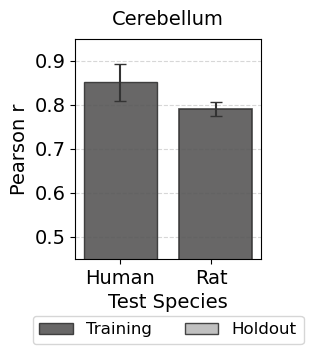

[Cerebellum] Model w/o rat: nan ± nan
[Cerebellum] Model w/ rat: 0.7896 ± 0.0159


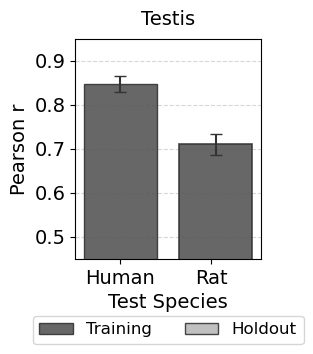

[Testis] Model w/o rat: nan ± nan
[Testis] Model w/ rat: 0.7101 ± 0.0246


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Colors
color_seen = "#575656"
color_unseen = "#BABABA"
darker_ecolor = "#333333"

for TISSUE in TISSUES_ORDER:

    x_positions = list(range(len(SPECIES_ORDER)))
    fig_width = max(3, 0.9 * len(x_positions))
    fig, ax = plt.subplots(figsize=(fig_width, 3.8))

    font_size = 14
    bar_width = 0.8

    leftout_wo_stats = (np.nan, np.nan)
    leftout_w_stats = (np.nan, np.nan)

    # Iterate through species
    for i, species in enumerate(SPECIES_ORDER):
        x_pos = x_positions[i]
        
        if species == LEFTOUT_SPECIES:
            # --- LEFTOUT SPECIES: Render overlapping bars ---
            mean_wo, std_wo = get_species_stats(
                df_usage_, MODEL_WITHOUT_LEFTOUT, LEFTOUT_SPECIES, target_tissue=TISSUE, model_head=USE_HEAD
            )
            mean_w, std_w = get_species_stats(
                df_usage_, MODEL_WITH_LEFTOUT, LEFTOUT_SPECIES, target_tissue=TISSUE, model_head=LEFTOUT_SPECIES
            )
            
            leftout_wo_stats = (mean_wo, std_wo)
            leftout_w_stats = (mean_w, std_w)
            delta = mean_w - mean_wo

            # Background bar: SEEN status (Model WITH species)
            bg_offset = 0.05
            ax.bar(
                x_pos + bg_offset,
                mean_w,
                yerr=std_w,
                width=bar_width,
                color=color_seen,
                ecolor=darker_ecolor,
                edgecolor=darker_ecolor,
                linewidth=1.2,
                alpha=0.9,
                capsize=4,
                zorder=2
            )

            # Foreground bar: UNSEEN status (Model WITHOUT species)
            fg_offset = -0.05
            ax.bar(
                x_pos + fg_offset,
                mean_wo,
                yerr=std_wo,
                width=bar_width,
                color=color_unseen,
                ecolor=darker_ecolor,
                edgecolor=darker_ecolor,
                linewidth=1.0,
                alpha=0.9,
                capsize=4,
                zorder=3
            )

            # Delta text above the overlapping bars
            if not np.isnan(delta):
                max_height = max(
                    mean_w + (std_w if not np.isnan(std_w) else 0),
                    mean_wo + (std_wo if not np.isnan(std_wo) else 0)
                )
                delta_str = f"$\Delta r$={delta*100:.1f}%"
                ax.text(
                    x_pos,
                    max_height + 0.02,
                    delta_str,
                    ha='center',
                    va='bottom',
                    color=darker_ecolor,
                    fontsize=font_size-1
                )
        else:
            # --- BASELINE SPECIES: Render single solid bar (SEEN) ---
            mean_val, std_val = get_species_stats(
                df_usage_, MODEL_WITHOUT_LEFTOUT, species, target_tissue=TISSUE, model_head=species
            )
            
            ax.bar(
                x_pos,
                mean_val,
                yerr=std_val,
                width=bar_width,
                color=color_seen,
                ecolor=darker_ecolor,
                edgecolor=darker_ecolor,
                linewidth=1.0,
                alpha=0.9,
                capsize=4
            )

    # --- Aesthetics and Styling ---
    ax.set_ylim(0.45, 0.95)
    ax.set_ylabel('Pearson r', fontsize=font_size)
    ax.set_xlabel('Test Species', fontsize=font_size)

    xtick_labels = [sp.capitalize() for sp in SPECIES_ORDER]
    ax.set_xticks(x_positions)

    ax.tick_params(axis='y', labelsize=font_size)
    ax.grid(axis='y', alpha=0.5, linestyle='--')
    ax.set_axisbelow(True)

    legend_handles = [
        mpatches.Patch(facecolor=color_seen, edgecolor=darker_ecolor, alpha=0.9, label='Training'),
        mpatches.Patch(facecolor=color_unseen, edgecolor=darker_ecolor, alpha=0.9, label='Holdout')
    ]

    if len(x_positions) < 3:

        ax.set_xticklabels(xtick_labels, fontsize=font_size, rotation=0, ha='center')
        ax.legend(
            handles=legend_handles,
            loc='upper center',
            bbox_to_anchor=(0.5, -0.22),  # Centered below the x-axis label
            ncol=2,                       # Side-by-side horizontal layout
            frameon=True,
            fontsize=font_size - 2
        )

    else:

        ax.set_xticklabels(xtick_labels, fontsize=font_size, rotation=45, ha='right')
        ax.legend(
            handles=legend_handles,
            loc='upper right',
            frameon=True,
            fontsize=font_size - 2
        )

    title_str = TISSUE if TISSUE else 'All Tissues'
    ax.set_title(title_str, fontsize=font_size, pad=10)

    plt.tight_layout()
    plt.show()

    print(f"[{title_str}] Model w/o {LEFTOUT_SPECIES}: {leftout_wo_stats[0]:.4f} ± {leftout_wo_stats[1]:.4f}")
    print(f"[{title_str}] Model w/ {LEFTOUT_SPECIES}: {leftout_w_stats[0]:.4f} ± {leftout_w_stats[1]:.4f}")

v3

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

# --- 1. Parameters & Colors ---
TISSUES_TO_PLOT = ['Liver', 'Cerebellum', 'Testis']
FONT_SIZE = 11
LEFTOUT_SPECIES = 'rat'
BASELINE_MODEL = 'human'
MODEL_WITH_LEFTOUT = 'human_mouse_rat_rabbit_opossum'

# --- 2. Fixed Metric Fetcher ---
def get_tissue_metrics(df, tissue_item):
    # Standardize to list format so .isin() works for both single tissues and lists of tissues
    tissues = tissue_item if isinstance(tissue_item, list) else [tissue_item]
    
    baseline_sub = df[
        (df['model'] == BASELINE_MODEL) & 
        (df['pred_species'] == LEFTOUT_SPECIES) &
        (df['tissue'].isin(tissues))
    ]
    rat_model_sub = df[
        (df['model'] == MODEL_WITH_LEFTOUT) & 
        (df['pred_species'] == LEFTOUT_SPECIES) & 
        (df['model_species'] == LEFTOUT_SPECIES) &
        (df['tissue'].isin(tissues))
    ]
        
    # Calculate overall mean Pearson r across filtered subset
    r_baseline = baseline_sub['correlation'].mean() if not baseline_sub.empty else 0.0
    r_full = rat_model_sub['correlation'].mean() if not rat_model_sub.empty else 0.0
    delta = r_full - r_baseline
    return r_baseline, r_full, delta

# --- 3. Generate Multi-Page PDF ---
pdf_filename = f'splicing_model_transfer_{LEFTOUT_SPECIES}.pdf'

pages_to_generate = [
    ('Liver', 'Liver'),
    ('Cerebellum', 'Cerebellum'),
    ('Testis', 'Testis'),
    (TISSUES_TO_PLOT, 'Liver, Cerebellum, Testis (Mean)')  # Page 4: Mean across 3 tissues
]

with PdfPages(pdf_filename) as pdf:
    for tissue_item, title_label in pages_to_generate:
        # Fetch r_baseline, r_full, and delta (averages over list if tissue_item is a list)
        r_baseline, r_full, delta = get_tissue_metrics(df_usage_, tissue_item)
        
        # Color Shading logic
        if isinstance(tissue_item, list):
            # Neutral slate tones for combined multi-tissue mean
            color_human = '#555555'
            color_rat = '#888888'
        else:
            base_hex = TISSUE_COLORS.get(tissue_item, '#333333')
            rgb_base = mcolors.to_rgb(base_hex)
            color_human = tuple(0.75 * c for c in rgb_base)
            color_rat = base_hex

        fig, ax = plt.subplots(figsize=(3, 2), dpi=300)
        x_pos = 0
        bar_width = 0.55

        # Base Model Bar (Rat -> Human)
        ax.bar(x_pos, r_baseline, width=bar_width, color=color_human, edgecolor='black', linewidth=0.8, zorder=3)

        # Delta Improvement Bar (Rat -> Rat)
        ax.bar(x_pos, delta, bottom=r_baseline, width=bar_width, color=color_rat, edgecolor='black', hatch='///', linewidth=0.8, zorder=3)

        # External Annotations (Side-aligned)
        right_edge_x = x_pos + (bar_width / 2) + 0.05
        plot_baseline = max(r_baseline, 0.5)
        plot_full = max(r_full, 0.5)
        plot_delta = max((delta / 2), 0.04)
        ax.text(right_edge_x, plot_baseline + 2*plot_delta, f"  $r = {r_full:.3f}$", ha='left', va='bottom', fontsize=FONT_SIZE)
        ax.text(right_edge_x, plot_baseline + plot_delta, f"$\Delta r = {delta:+.3f}$", ha='left', va='center', fontsize=FONT_SIZE)
        ax.text(right_edge_x, plot_baseline, f"  $r = {r_baseline:.3f}$", ha='left', va='top', fontsize=FONT_SIZE)

        # Legend (Bottom Right Corner)
        patch_human = mpatches.Patch(facecolor=color_human, edgecolor='black', linewidth=0.8, label='rat → human')
        patch_rat = mpatches.Patch(facecolor=color_rat, edgecolor='black', hatch='///', linewidth=0.8, label='rat → rat')
        
        # Expand x-axis slightly on the right to give the legend room
        ax.set_xlim(-0.35, 1.5)

        # Legend shifted further right
        leg = ax.legend(
            handles=[patch_rat, patch_human],
            title=r'$\mathrm{cis} \rightarrow \mathrm{trans}$',
            loc='lower left',
            bbox_to_anchor=(0.35, 0),  # Anchors the legend past the annotations
            frameon=False,
            fontsize=FONT_SIZE,
            title_fontsize=FONT_SIZE,
            handletextpad=0.5, handlelength=1.2, labelspacing=0.1
        )
        leg._legend_box.align = "left"

        ax.set_ylim(0.0, 1.0)
        ax.set_yticks([0.0, 0.5, 1.0])
        ax.set_ylabel('Pearson r', fontsize=FONT_SIZE)
        ax.set_title(title_label, fontsize=FONT_SIZE, pad=8)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.0)
        ax.spines['bottom'].set_linewidth(1.0)

        ax.tick_params(axis='both', labelsize=FONT_SIZE, length=2)
        ax.grid(axis='y', alpha=0.3, linestyle='--', color='#aaaaaa', zorder=1)
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.tick_params(axis='x', bottom=False)

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"Successfully generated all pages into {pdf_filename}")

<>:79: SyntaxWarning: invalid escape sequence '\D'
<>:79: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1883669/3562665656.py:79: SyntaxWarning: invalid escape sequence '\D'
  ax.text(right_edge_x, plot_baseline + plot_delta, f"$\Delta r = {delta:+.3f}$", ha='left', va='center', fontsize=FONT_SIZE)


Successfully generated all pages into splicing_model_transfer_rabbit.pdf


#### Usage 
Load usage data for all species and conditions (this takes some time).

In [ ]:
%%time

data_json_fn = f"{base_dir}/data/data_config.json"
with open(data_json_fn, 'r') as f:
    data_config = json.load(f)

species_list = list(data_config.keys())

usage_dfs = {}
for sps in species_list:
    parquet_path = os.path.expanduser(data_config[sps]["usage_parquet"])
    if not os.path.exists(parquet_path):
        print(f"Not found: {parquet_path}")
        continue
    df = pd.read_parquet(parquet_path)
    usage_dfs[sps] = df
    print(f"{sps}: {len(df):,} rows, columns: {list(df.columns)}")

human: 95,643,315 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
mouse: 95,763,380 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
rat: 120,197,320 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
rabbit: 63,199,928 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
opossum: 58,209,286 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
macaque: 4,438,132 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
chicken: 52,871,521 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
CPU times: user 52.1 s, sys: 1min 43s, total: 2min 35s
Wall time: 6min 7s


Count `n_sites` per condition and species.

In [ ]:
# Build a tidy DataFrame: species × condition → n_sites
# Condition labels come from data_config; usage parquet has one row per site×condition

records = []
for sps, df in usage_dfs.items():
    cond_labels = data_config[sps]["condition_labels"]  # name → index
    idx_to_name = {v: k for k, v in cond_labels.items()}
    known_indices = set(idx_to_name.keys())

    # Identify the condition column (may be named 'condition', 'condition_idx', etc.)
    cond_col = next((c for c in df.columns if "cond" in c.lower()), None)
    if cond_col is None:
        print(f"{sps}: no condition column found in {list(df.columns)}")
        continue

    counts = df[df[cond_col].isin(known_indices)].groupby(cond_col).size().reset_index(name="n_sites")
    for _, row in counts.iterrows():
        cond_idx = int(row[cond_col])
        records.append({
            "pred_species": sps,
            "condition_idx": cond_idx,
            "n_sites": int(row["n_sites"]),
        })

df_sites = pd.DataFrame(records)
print(f"Total rows: {len(df_sites)}")
df_sites.head(10)

# Make sure columns to merge in df_sites are the same type as in df_usage_
key_cols = ["pred_species", "condition_idx"]
for col in key_cols:
    if col in df_sites.columns and col in df_usage_.columns:
        df_sites[col] = df_sites[col].astype(df_usage_[col].dtype)

# Merge usage correlations with site counts
df_usage = df_usage_.merge(df_sites, on=key_cols, how="left")
df_usage['n_sites'] = df_usage['n_sites'].fillna(0).astype(int)
print(f"{len(df_usage)} usage records")
df_usage

Plot boxplot of usage correlation by condition, groupped by condition.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

pred_species_list = df_usage['pred_species'].unique()
pred_species_list = [s for s in SPECIES_ORDER if s in pred_species_list]
tissues = [t for t in TISSUE_ORDER if t in df_usage['tissue'].unique()]

# Build ordered list of (model, model_species) pairs
model_head_pairs = []
for model in sorted(df_usage['model'].unique()):
    model_species = model.split('_')
    for sps in SPECIES_ORDER:
        if sps in model_species:
            if ((df_usage['model'] == model) & (df_usage['model_species'] == sps)).any():
                model_head_pairs.append((model, sps))

n_rows = len(model_head_pairs)
n_species = len(pred_species_list)

fig, axes = plt.subplots(n_rows, n_species,
                         figsize=(n_species * 2.2, n_rows * 1.2),
                         squeeze=False, sharex=True, sharey=True)


for row_idx, (model, head_sps) in enumerate(model_head_pairs):
    first_visible_in_row = None  # track first non-empty axis in row
    
    for species_idx, pred_sps in enumerate(pred_species_list):
        ax = axes[row_idx, species_idx]
        subset = df_usage[
            (df_usage['model'] == model) &
            (df_usage['pred_species'] == pred_sps) &
            (df_usage['model_species'] == head_sps)
        ]
        if subset.empty:
            ax.axis('off')
            continue

        if first_visible_in_row is None:
            first_visible_in_row = ax
        box_data = [subset[subset['tissue'] == t]['correlation'].values for t in tissues]
        bp = ax.boxplot(
            [bd if len(bd) > 0 else [np.nan] for bd in box_data],
            positions=range(1, len(tissues) + 1),
            patch_artist=True,
            showfliers=False,
            widths=0.6
        )
        for patch, t in zip(bp['boxes'], tissues):
            patch.set_facecolor(TISSUE_COLORS.get(t, '#888888'))
            patch.set_alpha(0.6)
        for median, t in zip(bp['medians'], tissues):
            median.set_color(TISSUE_COLORS.get(t, '#888888'))
            median.set_linewidth(2)
        for pos, bd, t in zip(range(1, len(tissues) + 1), box_data, tissues):
            if len(bd) > 0:
                x_jitter = np.random.normal(pos, 0.07, size=len(bd))
                ax.scatter(x_jitter, bd, alpha=0.3, s=5,
                           color=TISSUE_COLORS.get(t, '#888888'))

        ax.set_ylim(0.35, 1.05)
        ax.set_xlim(0.5, len(tissues) + 0.5)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        if row_idx == 0:
            ax.set_title(pred_sps, fontsize=10)
        if species_idx == 0:
            model_display_name = model.replace('_', '+')
            model_display_name = '\n'.join(model_display_name.split('+'))
            ax.set_ylabel(f'{model_display_name}\n[{head_sps} head]\nPearson r', fontsize=8)

        ax.set_xticks(range(1, len(tissues) + 1))
        if row_idx == n_rows - 1:
            ax.set_xticklabels([t[:10] for t in tissues], rotation=45, ha='right', fontsize=8)
        else:
            ax.set_xticklabels([])

    # Set ylabel on first visible axis in row, regardless of which column it is
    if first_visible_in_row is not None:
        model_display_name = model.replace('_', '+')
        model_display_name = '\n'.join(model_display_name.split('+'))
        first_visible_in_row.set_ylabel(f'{model_display_name}\n[{head_sps} head]\nPearson r', fontsize=8)

legend_patches = [mpatches.Patch(color=TISSUE_COLORS[t], alpha=0.7, label=t) for t in tissues]
fig.legend(handles=legend_patches, title='Tissue',
           loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
fig.suptitle('Usage Prediction Performance', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Single plot with all tissues on x-axis

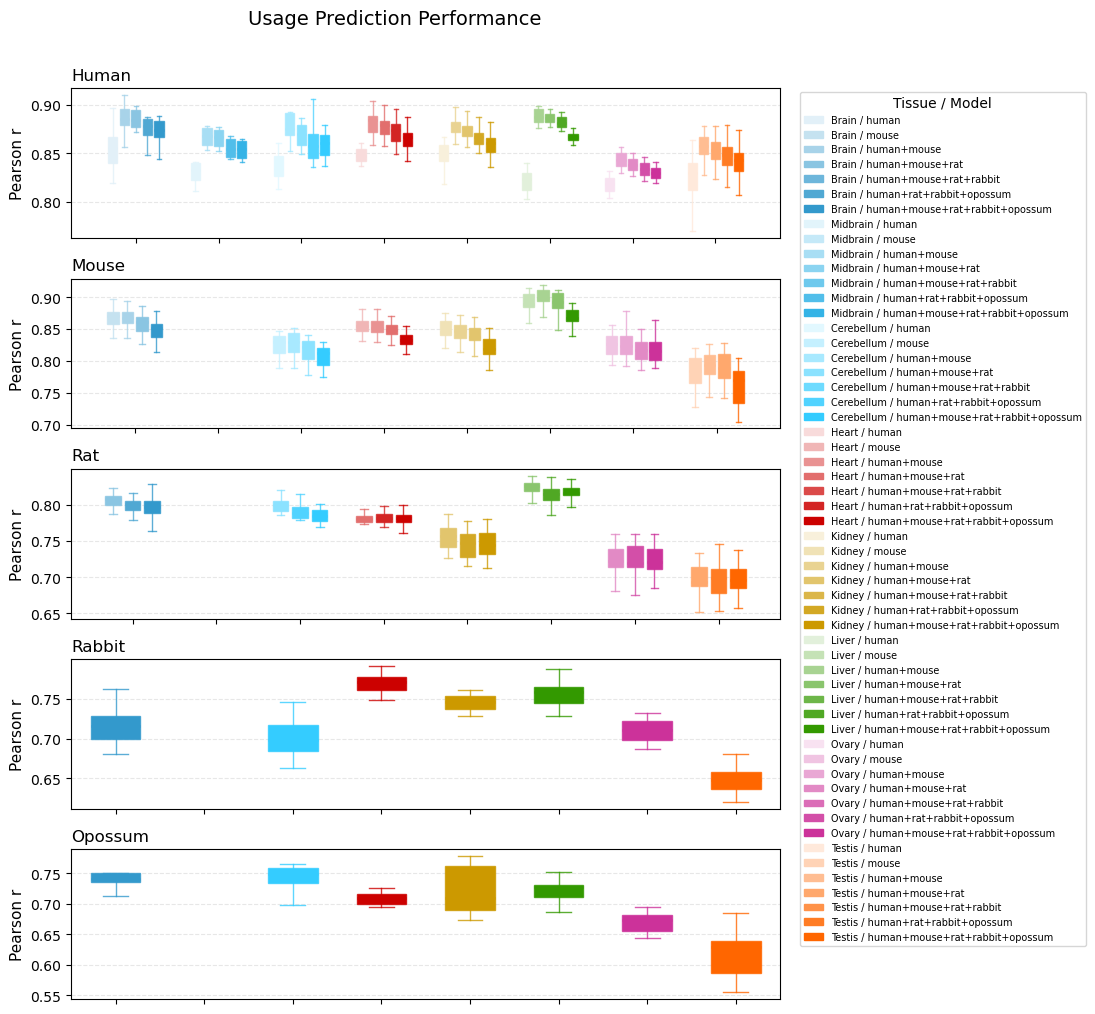

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


pred_species_list = df_usage['pred_species'].unique()
pred_species_list = [s for s in SPECIES_ORDER if s in pred_species_list]
tissues = ['Brain', 'Midbrain', 'Cerebellum', 'Heart', 'Kidney', 'Liver', 'Ovary', 'Testis']
tissues = [t for t in tissues if t in df_usage['tissue'].unique()]

n_species = len(pred_species_list)
n_tissues = len(tissues)

fig, axes = plt.subplots(n_species, 1, figsize=(8, n_species * 2), squeeze=False)
axes = axes.flatten()

for species_idx, pred_sps in enumerate(pred_species_list):
    ax = axes[species_idx]
    species_data = df_usage[(df_usage['pred_species'] == pred_sps) & (df_usage['model_species'] == pred_sps)]

    groups = [m for m in models if m in species_data['model'].unique()]
    n_groups = len(groups)
    
    box_width = 0.7 / n_groups if n_groups > 0 else 0.7

    for tissue_idx, tissue in enumerate(tissues):
        tissue_data = species_data[species_data['tissue'] == tissue]
        for group_idx, model in enumerate(groups):
            group_data = tissue_data[tissue_data['model'] == model]
            if len(group_data) > 0:
                correlations = group_data['correlation'].values
                x_pos = tissue_idx + (group_idx - n_groups / 2 + 0.5) * box_width
                color = TISSUE_MODEL_COLORS[tissue].get(model, '#888888')
                edge_color = plt.cm.colors.to_rgba(color, alpha=0.8)  # slightly darker shade for edge
                ax.boxplot([correlations], positions=[x_pos], widths=box_width * 0.8,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(color=edge_color, facecolor=color),
                    medianprops=dict(color=color, linewidth=2),
                    whiskerprops=dict(color=edge_color),
                    capprops=dict(color=edge_color))
                x_jitter = np.random.normal(x_pos, box_width * 0.1, size=len(correlations))
                #ax.scatter(x_jitter, correlations, alpha=0.4, s=10, color=color, edgecolors='black', linewidths=0.3)
                ax.set_xticks(range(n_tissues))
                ax.set_xticklabels([])
                ax.set_ylabel('Pearson r', fontsize=11)
                ax.set_title(pred_sps.capitalize(), fontsize=12, loc='left')
                #ax.set_ylim(0.55, 1.05)
                ax.grid(axis='y', alpha=0.3, linestyle='--')

# Legend: one entry per (model, head_sps) pair
from matplotlib.lines import Line2D
legend_handles = []
for tissue in tissues:
    for model in models:
        color = TISSUE_MODEL_COLORS[tissue].get(model, '#888888')
        legend_handles.append(mpatches.Patch(color=color, label=f'{tissue} / {model.replace("_", "+")}'))

fig.legend(handles=legend_handles, title='Tissue / Model',
loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=7, ncol=1)
fig.suptitle('Usage Prediction Performance', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Summary

In [ ]:
# Summary: Classification AUPRC by model and species
summary_classification = df_classification.groupby(['model', 'pred_species'])['auprc'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std')
]).round(3)
print("Classification AUPRC Summary:")
display(summary_classification.round(3))

Classification AUPRC Summary:


mean  median    std
model                          pred_species                      
human                          human         0.887   0.887  0.007
                               mouse         0.945   0.946  0.004
                               opossum       0.871   0.868  0.016
                               rabbit        0.859   0.860  0.026
                               rat           0.915   0.914  0.008
human_mouse                    human         0.906   0.907  0.005
                               mouse         0.963   0.962  0.003
                               opossum       0.893   0.892  0.010
                               rabbit        0.880   0.883  0.017
                               rat           0.938   0.938  0.002
human_mouse_rat                human         0.898   0.899  0.005
                               mouse         0.963   0.962  0.003
                               opossum       0.889   0.887  0.012
                               rabbit        0.875   0.878  0.019
                               rat           0.938   0.939  0.001
human_mouse_rat_rabbit_opossum human         0.886   0.885  0.002
                               mouse         0.953   0.953  0.003
                               opossum       0.898   0.898  0.010
                               rabbit        0.921   0.924  0.007
                               rat           0.938   0.938  0.002
human_rat_rabbit_opossum       human         0.898   0.898  0.004
                               mouse         0.957   0.957  0.003
                               rat           0.939   0.940  0.001
mouse                          human         0.898   0.899  0.005
                               mouse         0.963   0.963  0.002
                               opossum       0.887   0.891  0.017
                               rabbit        0.864   0.869  0.021
                               rat           0.931   0.932  0.003

In [ ]:
# Exclude conditions
#blacklist = ['Brain_4', 'Brain_8', 'Cerebellum_1', 'Cerebellum_2', 'Cerebellum_3', 'Cerebellum_14', 'Cerebellum_15']
#df_usage = df_usage[~df_usage['condition_name'].isin(blacklist)]

# Summary: Usage correlations by model and tissue
summary_usage = df_usage.groupby(['tissue', 'model', 'model_species', 'pred_species'])['correlation'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('n_conditions', 'count')
]).round(2)

print("Usage Correlation Summary by Tissue and Model:")
display(summary_usage)

# Overall Summary: Usage correlations by model
overall_summary = df_usage.groupby(['model', 'model_species', 'pred_species'])['correlation'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('n_conditions', 'count')
]).round(2)

print("\nOverall Usage Correlation Summary by Model:")
display(overall_summary)

Usage Correlation Summary by Tissue and Model:


mean  median   std  n_conditions
tissue model model_species pred_species                                  
Brain  human human         human         0.85    0.86  0.02            15
                           mouse         0.82    0.82  0.02            14
                           opossum       0.62    0.63  0.04            13
                           rabbit        0.58    0.57  0.02            14
                           rat           0.75    0.76  0.02            14
...                                       ...     ...   ...           ...
Testis mouse mouse         human         0.81    0.81  0.04            14
                           mouse         0.78    0.78  0.03            14
                           opossum       0.56    0.56  0.03            10
                           rabbit        0.52    0.51  0.04            13
                           rat           0.69    0.68  0.03            13

[327 rows x 4 columns]


Overall Usage Correlation Summary by Model:


mean  median   std  \
model                          model_species pred_species                       
human                          human         human         0.84    0.84  0.03   
                                             mouse         0.78    0.80  0.08   
                                             opossum       0.59    0.60  0.07   
                                             rabbit        0.57    0.58  0.06   
                                             rat           0.71    0.74  0.08   
human_mouse                    human         human         0.88    0.88  0.02   
                                             mouse         0.81    0.83  0.08   
                                             opossum       0.61    0.61  0.06   
                                             rabbit        0.59    0.60  0.06   
                                             rat           0.74    0.77  0.08   
                               mouse         human         0.85    0.86  0.05   
                                             mouse         0.84    0.85  0.04   
                                             opossum       0.63    0.63  0.04   
                                             rabbit        0.61    0.61  0.05   
                                             rat           0.76    0.77  0.04   
human_mouse_rat                human         human         0.87    0.87  0.02   
                                             opossum       0.63    0.64  0.07   
                                             rabbit        0.63    0.64  0.06   
                               mouse         mouse         0.84    0.84  0.04   
                                             opossum       0.65    0.65  0.04   
                                             rabbit        0.65    0.65  0.05   
                               rat           opossum       0.66    0.66  0.04   
                                             rabbit        0.67    0.67  0.04   
                                             rat           0.77    0.78  0.05   
human_mouse_rat_rabbit_opossum human         human         0.86    0.86  0.02   
                               mouse         mouse         0.82    0.82  0.04   
                               opossum       opossum       0.71    0.71  0.05   
                               rabbit        rabbit        0.72    0.73  0.05   
                               rat           rat           0.76    0.78  0.05   
human_rat_rabbit_opossum       human         human         0.86    0.87  0.02   
                                             mouse         0.80    0.81  0.07   
                                             rat           0.71    0.74  0.08   
                               opossum       human         0.81    0.82  0.06   
                                             mouse         0.79    0.80  0.04   
                                             rat           0.75    0.77  0.05   
                               rabbit        human         0.82    0.83  0.06   
                                             mouse         0.80    0.81  0.05   
                                             rat           0.76    0.77  0.05   
                               rat           human         0.83    0.84  0.06   
                                             mouse         0.81    0.82  0.04   
                                             rat           0.77    0.78  0.05   
mouse                          mouse         human         0.84    0.85  0.05   
                                             mouse         0.84    0.85  0.04   
                                             opossum       0.62    0.62  0.04   
                                             rabbit        0.59    0.59  0.05   
                                             rat           0.75    0.76  0.04   

                                                           n_conditions  
model                          model_species pred_species                
human                 

,model,pred_species,mean,std
1,human_mouse,human,0.88,0.02
3,human_mouse_rat,human,0.87,0.02
11,human_rat_rabbit_opossum,human,0.86,0.02
6,human_mouse_rat_rabbit_opossum,human,0.86,0.02
0,human,human,0.84,0.03
2,human_mouse,mouse,0.84,0.04
13,mouse,mouse,0.84,0.04
4,human_mouse_rat,mouse,0.84,0.04
7,human_mouse_rat_rabbit_opossum,mouse,0.82,0.04
5,human_mouse_rat,rat,0.77,0.05


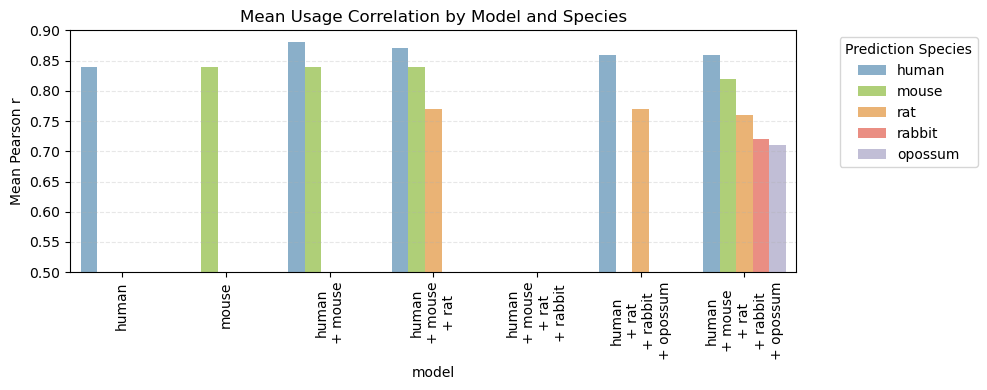

In [ ]:
# Subset where usage_head_species and pred_species match
top_summary = overall_summary.reset_index()
top_summary = top_summary[top_summary['model_species'] == top_summary['pred_species']]
# Order by pred_species, then mean correlation
top_summary = top_summary.reset_index()
top_summary = top_summary.sort_values(by=['mean'], ascending=[False])
# Subset columns to show
top_summary = top_summary[['model', 'pred_species', 'mean', 'std']]
display(top_summary)
# Models as categorical for plotting order
top_summary['model'] = pd.Categorical(top_summary['model'], categories=models, ordered=True)

import seaborn as sns

# Plot as barplot with error bars
plt.figure(figsize=(10, 4))
sns.barplot(data=top_summary, x='model', y='mean', hue='pred_species', palette=SPECIES_COLORS, capsize=0.1)
plt.xticks(rotation=45, ha='right')
plt.xticks(ticks=range(len(models)), labels=[m.replace('_', '\n+ ') for m in models], rotation=90, ha='center', va='top')
plt.ylabel('Mean Pearson r')  
plt.ylim(0.5, 0.9)
plt.title('Mean Usage Correlation by Model and Species')
plt.legend(title='Prediction Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()